<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/Track_C_Stage_2_Loss_Function_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =====================================================
# TRACK C: ULTIMATE STAGE 2 COMPARISON
# 119 Experiments with Smart Checkpointing
# =====================================================

import os
import sys
import json
import pickle
from datetime import datetime
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge as RidgeRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*70)
print("TRACK C: ULTIMATE STAGE 2 MODEL COMPARISON")
print("119 Experiments with Smart Checkpointing")
print("CPU for sklearn | GPU for deep learning")
print("="*70)

# =====================================================
# 1. CONFIGURATION
# =====================================================

BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
DATA_DIR = os.path.join(BASE_DIR, "Multi_Task_Implementation")
TRACK_C_DIR = os.path.join(BASE_DIR, "Track_C_Stage2_Loss")
ROUND1_DIR = os.path.join(TRACK_C_DIR, "Round1_Ultimate")

CHECKPOINT_DIR = os.path.join(ROUND1_DIR, "checkpoints")
RESULTS_DIR = os.path.join(ROUND1_DIR, "results")
PROGRESS_FILE = os.path.join(ROUND1_DIR, "progress.json")

os.makedirs(TRACK_C_DIR, exist_ok=True)
os.makedirs(ROUND1_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train_multitask.pt")
VAL_FILE = os.path.join(DATA_DIR, "dataset_val_multitask.pt")
TEST_FILE = os.path.join(DATA_DIR, "dataset_test_multitask.pt")
L1B_GLOBAL = os.path.join(DATA_DIR, "l1b_global_feature.pt")

DEVICE_GPU = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_CPU = "cpu"

BATCH_SIZE = 32
MLP_EPOCHS = 50
LEARNING_RATE = 1e-4
PATIENCE = 15

print(f"✓ GPU Device: {DEVICE_GPU}")
print(f"✓ CPU Device: {DEVICE_CPU}")
print(f"✓ Checkpoints: {CHECKPOINT_DIR}")
print(f"✓ Progress tracker: {PROGRESS_FILE}\n")

# =====================================================
# 2. HYPERPARAMETER GRIDS
# =====================================================

HYPERPARAMS = {
    'ridge': {'alpha': [0.1, 1, 10, 100]},
    'krr': {'gamma': [0.001, 0.01, 0.1]},
    'svr': {'C': [1, 10, 100], 'gamma': [0.01, 0.1], 'kernel': ['rbf', 'poly']},
    'gbr': {'learning_rate': [0.05, 0.1], 'n_estimators': [200, 300], 'max_depth': [4, 6]},
    'rf': {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]},
    'mlp_simp': {'loss': ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']},
    'mlp_gelu': {'loss': ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']},
    'transformer': {'loss': ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']}
}

# =====================================================
# 3. BUILD EXPERIMENT REGISTRY
# =====================================================

def build_experiment_registry():
    experiments = {}

    for model_name in ['ridge', 'krr', 'svr', 'gbr', 'rf']:
        params = HYPERPARAMS[model_name]
        param_names = list(params.keys())
        param_values = list(params.values())

        for param_combo in product(*param_values):
            param_dict = dict(zip(param_names, param_combo))

            for aug in ['NOA', 'MX2']:
                param_str = '-'.join([f"{k[:3]}{str(v).replace('.', '')[:4]}" for k, v in param_dict.items()])
                exp_id = f"C-{model_name.upper()}-{param_str}-{aug}"

                experiments[exp_id] = {
                    'model': model_name,
                    'device': 'cpu',
                    'hyperparams': param_dict,
                    'augmentation': 'mixup' if aug=='MX2' else 'none',
                    'mixup_alpha': 0.2 if aug=='MX2' else 0.0,
                    'epochs': 0
                }

    for model_name in ['mlp_simp', 'mlp_gelu', 'transformer']:
        for loss in HYPERPARAMS[model_name]['loss']:
            for aug in ['NOA', 'MX2']:
                exp_id = f"C-{model_name.upper().replace('_', '-')}-{loss}-{aug}"

                experiments[exp_id] = {
                    'model': model_name,
                    'device': 'gpu',
                    'loss': loss.lower(),
                    'loss_param': 0.3 if loss=='RA3' else 0.5 if loss=='RA5' else 0.7 if loss=='RA7' else 1.0 if loss=='FC1' else 2.0 if loss=='FC2' else None,
                    'augmentation': 'mixup' if aug=='MX2' else 'none',
                    'mixup_alpha': 0.2 if aug=='MX2' else 0.0,
                    'epochs': MLP_EPOCHS
                }

    return experiments

experiments = build_experiment_registry()

print(f"✓ Built registry: {len(experiments)} experiments")
print(f"  - CPU (sklearn): {sum(1 for e in experiments.values() if e['device']=='cpu')}")
print(f"  - GPU (deep):    {sum(1 for e in experiments.values() if e['device']=='gpu')}")

registry_path = os.path.join(ROUND1_DIR, "experiment_registry.json")
with open(registry_path, 'w') as f:
    json.dump(experiments, f, indent=2)
print(f"✓ Saved: {registry_path}\n")

# =====================================================
# 4. PROGRESS TRACKING - FIXED WITH AUTO-RECOVERY
# =====================================================

def load_progress():
    """Load progress tracker with auto-recovery from corruption"""
    if os.path.exists(PROGRESS_FILE):
        try:
            with open(PROGRESS_FILE, 'r') as f:
                return json.load(f)
        except (json.JSONDecodeError, ValueError) as e:
            print(f"⚠️  Corrupted progress file detected: {e}")
            print(f"⚠️  Creating backup and starting fresh...")

            # Backup corrupted file
            backup_path = PROGRESS_FILE.replace('.json', '_corrupted_backup.json')
            if os.path.exists(PROGRESS_FILE):
                import shutil
                shutil.copy(PROGRESS_FILE, backup_path)
                print(f"✓ Backed up to: {backup_path}")

            # Return fresh progress
            return {'completed': [], 'failed': [], 'results': []}

    return {'completed': [], 'failed': [], 'results': []}

def save_progress(progress):
    """Save progress tracker - handles numpy types"""
    def convert_types(obj):
        if isinstance(obj, dict):
            return {k: convert_types(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_types(v) for v in obj]
        elif isinstance(obj, (np.integer, np.floating)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (np.bool_)):
            return bool(obj)
        return obj

    progress_clean = convert_types(progress)

    # Write to temp file first, then rename (atomic operation)
    temp_file = PROGRESS_FILE + '.tmp'
    with open(temp_file, 'w') as f:
        json.dump(progress_clean, f, indent=2)

    # Atomic rename
    import shutil
    shutil.move(temp_file, PROGRESS_FILE)

def is_completed(exp_id, progress):
    return exp_id in progress['completed']

def mark_completed(exp_id, progress, result):
    if exp_id not in progress['completed']:
        progress['completed'].append(exp_id)
    progress['results'].append(result)
    save_progress(progress)

def mark_failed(exp_id, progress, error):
    fail_entry = {'exp_id': exp_id, 'error': str(error)}
    if fail_entry not in progress['failed']:
        progress['failed'].append(fail_entry)
    save_progress(progress)

progress = load_progress()
print(f"✓ Progress tracker loaded:")
print(f"  - Completed: {len(progress['completed'])}")
print(f"  - Failed: {len(progress['failed'])}")
print(f"  - Remaining: {len(experiments) - len(progress['completed'])}\n")

# =====================================================
# 5. LOSS FUNCTIONS
# =====================================================

class RangeAwareLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
    def forward(self, pred, target, target_range):
        mae = torch.abs(pred - target)
        target_min, target_max = target_range
        target_norm = (target - target_min) / (target_max - target_min + 1e-6)
        weight = 1.0 + self.alpha * torch.abs(2 * target_norm - 1)
        return (mae * weight).mean()

class FocalRegressionLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, pred, target):
        mae = torch.abs(pred - target)
        mae_norm = mae / (mae.max() + 1e-6)
        weight = (1 - torch.exp(-mae_norm)) ** self.gamma
        return (mae * weight).mean()

class QuantileLoss(nn.Module):
    def forward(self, q10, q50, q90, target):
        def pinball(pred, target, tau):
            error = target - pred
            return torch.max(tau * error, (tau - 1) * error).mean()
        return pinball(q10, target, 0.1) + pinball(q50, target, 0.5) + pinball(q90, target, 0.9)

def mixup_data(x, y, alpha=0.2, device='cuda'):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    return lam * x + (1 - lam) * x[index, :], lam * y + (1 - lam) * y[index]

def mixup_numpy(X, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    index = np.random.permutation(X.shape[0])
    return lam * X + (1 - lam) * X[index, :], lam * y + (1 - lam) * y[index]

print("✓ Loss functions defined\n")

# =====================================================
# 6. MODEL ARCHITECTURES
# =====================================================

class MLPSimple(nn.Module):
    def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
        super().__init__()
        self.quantile_mode = quantile_mode
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.GELU(),
            nn.Linear(512, 256), nn.GELU(),
            nn.Linear(256, 128)
        )
        self.l1b_processor = nn.Sequential(
            nn.Linear(l1b_dim, 128), nn.GELU(),
            nn.Linear(128, 64)
        )
        hidden_dim = 192

        if quantile_mode:
            self.head_rh_q10 = nn.Linear(hidden_dim, 1)
            self.head_rh_q50 = nn.Linear(hidden_dim, 1)
            self.head_rh_q90 = nn.Linear(hidden_dim, 1)
            self.head_pai_q10 = nn.Linear(hidden_dim, 1)
            self.head_pai_q50 = nn.Linear(hidden_dim, 1)
            self.head_pai_q90 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
        else:
            self.head_rh = nn.Sequential(nn.Linear(hidden_dim, 64), nn.GELU(), nn.Linear(64, 1))
            self.head_pai = nn.Sequential(nn.Linear(hidden_dim, 64), nn.GELU(), nn.Linear(64, 1))
            self.head_fhd = nn.Sequential(nn.Linear(hidden_dim, 64), nn.GELU(), nn.Linear(64, 1))

    def forward(self, x, l1b_global):
        features = self.encoder(x)
        l1b_features = self.l1b_processor(l1b_global)
        if l1b_features.dim() == 1:
            l1b_features = l1b_features.unsqueeze(0).expand(x.size(0), -1)
        combined = torch.cat([features, l1b_features], dim=1)

        if self.quantile_mode:
            return ((self.head_rh_q10(combined).squeeze(-1), self.head_rh_q50(combined).squeeze(-1), self.head_rh_q90(combined).squeeze(-1)),
                    (self.head_pai_q10(combined).squeeze(-1), self.head_pai_q50(combined).squeeze(-1), self.head_pai_q90(combined).squeeze(-1)),
                    (self.head_fhd_q10(combined).squeeze(-1), self.head_fhd_q50(combined).squeeze(-1), self.head_fhd_q90(combined).squeeze(-1)))
        return self.head_rh(combined).squeeze(-1), self.head_pai(combined).squeeze(-1), self.head_fhd(combined).squeeze(-1)

class MLPGELU(nn.Module):
    def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
        super().__init__()
        self.quantile_mode = quantile_mode
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048), nn.LayerNorm(2048), nn.GELU(),
            nn.Linear(2048, 1024), nn.LayerNorm(1024), nn.GELU(),
            nn.Linear(1024, 512), nn.LayerNorm(512), nn.GELU()
        )
        self.l1b_processor = nn.Sequential(
            nn.Linear(l1b_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, 128)
        )
        hidden_dim = 640

        if quantile_mode:
            self.head_rh_q10 = nn.Linear(hidden_dim, 1)
            self.head_rh_q50 = nn.Linear(hidden_dim, 1)
            self.head_rh_q90 = nn.Linear(hidden_dim, 1)
            self.head_pai_q10 = nn.Linear(hidden_dim, 1)
            self.head_pai_q50 = nn.Linear(hidden_dim, 1)
            self.head_pai_q90 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
        else:
            self.head_rh = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))
            self.head_pai = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))
            self.head_fhd = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))

    def forward(self, x, l1b_global):
        features = self.encoder(x)
        l1b_features = self.l1b_processor(l1b_global)
        if l1b_features.dim() == 1:
            l1b_features = l1b_features.unsqueeze(0).expand(x.size(0), -1)
        combined = torch.cat([features, l1b_features], dim=1)

        if self.quantile_mode:
            return ((self.head_rh_q10(combined).squeeze(-1), self.head_rh_q50(combined).squeeze(-1), self.head_rh_q90(combined).squeeze(-1)),
                    (self.head_pai_q10(combined).squeeze(-1), self.head_pai_q50(combined).squeeze(-1), self.head_pai_q90(combined).squeeze(-1)),
                    (self.head_fhd_q10(combined).squeeze(-1), self.head_fhd_q50(combined).squeeze(-1), self.head_fhd_q90(combined).squeeze(-1)))
        return self.head_rh(combined).squeeze(-1), self.head_pai(combined).squeeze(-1), self.head_fhd(combined).squeeze(-1)

class TransformerMultiTask(nn.Module):
    def __init__(self, embed_dim=96, num_tokens=64, num_modalities=8, l1b_dim=384, quantile_mode=False):
        super().__init__()
        self.num_modalities = num_modalities
        self.num_tokens = num_tokens
        self.embed_dim = embed_dim
        self.quantile_mode = quantile_mode

        self.modality_embed = nn.Parameter(torch.randn(num_modalities, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(num_tokens, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=8, dim_feedforward=384, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        self.l1b_processor = nn.Sequential(
            nn.Linear(l1b_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, embed_dim)
        )

        hidden_dim = embed_dim * 2

        if quantile_mode:
            self.head_rh_q10 = nn.Linear(hidden_dim, 1)
            self.head_rh_q50 = nn.Linear(hidden_dim, 1)
            self.head_rh_q90 = nn.Linear(hidden_dim, 1)
            self.head_pai_q10 = nn.Linear(hidden_dim, 1)
            self.head_pai_q50 = nn.Linear(hidden_dim, 1)
            self.head_pai_q90 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
            self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
        else:
            self.head_rh = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))
            self.head_pai = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))
            self.head_fhd = nn.Sequential(nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, 1))

    def forward(self, x, l1b_global):
        batch_size = x.size(0)
        x = x.view(batch_size, self.num_modalities, self.num_tokens, self.embed_dim)

        tokens = []
        for mod_idx in range(self.num_modalities):
            mod_tokens = x[:, mod_idx, :, :] + self.pos_embed.unsqueeze(0) + self.modality_embed[mod_idx].unsqueeze(0).unsqueeze(0)
            tokens.append(mod_tokens)

        all_tokens = torch.cat(tokens, dim=1)
        transformed = self.transformer(all_tokens)
        pooled = transformed.mean(dim=1)

        l1b_features = self.l1b_processor(l1b_global)
        if l1b_features.dim() == 1:
            l1b_features = l1b_features.unsqueeze(0).expand(batch_size, -1)

        combined = torch.cat([pooled, l1b_features], dim=1)

        if self.quantile_mode:
            return ((self.head_rh_q10(combined).squeeze(-1), self.head_rh_q50(combined).squeeze(-1), self.head_rh_q90(combined).squeeze(-1)),
                    (self.head_pai_q10(combined).squeeze(-1), self.head_pai_q50(combined).squeeze(-1), self.head_pai_q90(combined).squeeze(-1)),
                    (self.head_fhd_q10(combined).squeeze(-1), self.head_fhd_q50(combined).squeeze(-1), self.head_fhd_q90(combined).squeeze(-1)))
        return self.head_rh(combined).squeeze(-1), self.head_pai(combined).squeeze(-1), self.head_fhd(combined).squeeze(-1)

print("✓ Model architectures defined\n")

# =====================================================
# 7. DATA LOADING
# =====================================================

print("Loading data...")

dataset_train = torch.load(TRAIN_FILE, weights_only=False)
dataset_val = torch.load(VAL_FILE, weights_only=False)
dataset_test = torch.load(TEST_FILE, weights_only=False)
l1b_global_feature = torch.load(L1B_GLOBAL, weights_only=False)

print(f"✓ Train: {len(dataset_train)}, Val: {len(dataset_val)}, Test: {len(dataset_test)}")

def extract_data(dataset):
    embeddings, rh_targets, pai_targets, fhd_targets = [], [], [], []
    for sample in dataset:
        embeddings.append(sample['embeddings'].flatten())
        rh_targets.append(sample['rh'].item())
        pai_targets.append(sample['pai'].item())
        fhd_targets.append(sample['fhd'].item())
    return torch.stack(embeddings).numpy(), np.array(rh_targets), np.array(pai_targets), np.array(fhd_targets)

X_train, y_train_rh, y_train_pai, y_train_fhd = extract_data(dataset_train)
X_val, y_val_rh, y_val_pai, y_val_fhd = extract_data(dataset_val)
X_test, y_test_rh, y_test_pai, y_test_fhd = extract_data(dataset_test)

class MultiTaskDataset(Dataset):
    def __init__(self, X, y_rh, y_pai, y_fhd):
        self.X = torch.FloatTensor(X)
        self.y_rh = torch.FloatTensor(y_rh)
        self.y_pai = torch.FloatTensor(y_pai)
        self.y_fhd = torch.FloatTensor(y_fhd)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y_rh[idx], self.y_pai[idx], self.y_fhd[idx]

train_dataset = MultiTaskDataset(X_train, y_train_rh, y_train_pai, y_train_fhd)
val_dataset = MultiTaskDataset(X_val, y_val_rh, y_val_pai, y_val_fhd)
test_dataset = MultiTaskDataset(X_test, y_test_rh, y_test_pai, y_test_fhd)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

rh_range = (y_train_rh.min(), y_train_rh.max())
pai_range = (y_train_pai.min(), y_train_pai.max())
fhd_range = (y_train_fhd.min(), y_train_fhd.max())

print(f"✓ RH range: {rh_range[0]:.2f} - {rh_range[1]:.2f}\n")

# =====================================================
# 8. TRAINING FUNCTIONS
# =====================================================

def train_sklearn_model(exp_config, X_train, y_train, X_test, y_test):
    if exp_config['augmentation'] == 'mixup':
        X_aug, y_aug = mixup_numpy(X_train, y_train, exp_config['mixup_alpha'])
    else:
        X_aug, y_aug = X_train, y_train

    model_name = exp_config['model']
    params = exp_config['hyperparams']

    if model_name == 'ridge':
        model = RidgeRegression(**params)
    elif model_name == 'krr':
        model = KernelRidge(alpha=1.0, kernel='rbf', **params)
    elif model_name == 'svr':
        model = SVR(**params, epsilon=0.1)
    elif model_name == 'gbr':
        model = GradientBoostingRegressor(**params, subsample=0.8, random_state=42)
    elif model_name == 'rf':
        model = RandomForestRegressor(**params, bootstrap=True, random_state=42, n_jobs=-1)

    model.fit(X_aug, y_aug)
    y_pred = model.predict(X_test)

    return model, {
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred),
        'pred_std': y_pred.std(),
        'pred_range': y_pred.max() - y_pred.min()
    }

def train_deep_model(exp_config, train_loader, val_loader, test_loader, l1b_global, device):
    quantile_mode = (exp_config.get('loss') == 'qnt')
    model_name = exp_config['model']

    if model_name == 'mlp_simp':
        model = MLPSimple(quantile_mode=quantile_mode).to(device)
    elif model_name == 'mlp_gelu':
        model = MLPGELU(quantile_mode=quantile_mode).to(device)
    elif model_name == 'transformer':
        model = TransformerMultiTask(quantile_mode=quantile_mode).to(device)

    l1b_tensor = l1b_global.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    loss_name = exp_config.get('loss', 'mse')
    if loss_name in ['ra3', 'ra5', 'ra7']:
        alpha = exp_config['loss_param']
        criterion_rh = RangeAwareLoss(alpha=alpha)
        criterion_pai = RangeAwareLoss(alpha=alpha)
        criterion_fhd = RangeAwareLoss(alpha=alpha)
    elif loss_name in ['fc1', 'fc2']:
        gamma = exp_config['loss_param']
        criterion_rh = FocalRegressionLoss(gamma=gamma)
        criterion_pai = FocalRegressionLoss(gamma=gamma)
        criterion_fhd = FocalRegressionLoss(gamma=gamma)
    elif loss_name == 'qnt':
        criterion = QuantileLoss()
    elif loss_name == 'mse':
        criterion_rh = nn.MSELoss()
        criterion_pai = nn.MSELoss()
        criterion_fhd = nn.MSELoss()
    else:
        criterion_rh = nn.L1Loss()
        criterion_pai = nn.L1Loss()
        criterion_fhd = nn.L1Loss()

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    use_mixup = (exp_config['augmentation'] == 'mixup')
    mixup_alpha = exp_config['mixup_alpha']

    for epoch in range(exp_config['epochs']):
        model.train()
        for X_batch, rh_batch, pai_batch, fhd_batch in train_loader:
            X_batch = X_batch.to(device)
            rh_batch = rh_batch.to(device)
            pai_batch = pai_batch.to(device)
            fhd_batch = fhd_batch.to(device)

            if use_mixup and np.random.rand() < 0.5:
                X_batch, rh_batch = mixup_data(X_batch, rh_batch, mixup_alpha, device)
                X_batch, pai_batch = mixup_data(X_batch, pai_batch, mixup_alpha, device)
                X_batch, fhd_batch = mixup_data(X_batch, fhd_batch, mixup_alpha, device)

            optimizer.zero_grad()
            pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

            if loss_name == 'qnt':
                loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
                loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
                loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
            elif loss_name in ['ra3', 'ra5', 'ra7']:
                loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
                loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
                loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
            else:
                loss_rh = criterion_rh(pred_rh, rh_batch)
                loss_pai = criterion_pai(pred_pai, pai_batch)
                loss_fhd = criterion_fhd(pred_fhd, fhd_batch)

            loss = loss_rh + loss_pai + loss_fhd
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        val_preds_rh = []

        with torch.no_grad():
            for X_batch, rh_batch, pai_batch, fhd_batch in val_loader:
                X_batch = X_batch.to(device)
                rh_batch = rh_batch.to(device)
                pai_batch = pai_batch.to(device)
                fhd_batch = fhd_batch.to(device)

                pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

                if loss_name == 'qnt':
                    loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
                    loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
                    loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
                    pred_rh_val = pred_rh[1]
                elif loss_name in ['ra3', 'ra5', 'ra7']:
                    loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
                    loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
                    loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
                    pred_rh_val = pred_rh
                else:
                    loss_rh = criterion_rh(pred_rh, rh_batch)
                    loss_pai = criterion_pai(pred_pai, pai_batch)
                    loss_fhd = criterion_fhd(pred_fhd, fhd_batch)
                    pred_rh_val = pred_rh

                loss = loss_rh + loss_pai + loss_fhd
                val_loss += loss.item() * X_batch.size(0)
                val_preds_rh.append(pred_rh_val.cpu())

        val_loss /= len(val_loader.dataset)
        val_std = torch.cat(val_preds_rh).numpy().std()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if val_std < 0.2 or patience_counter >= PATIENCE:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    test_preds_rh, test_preds_pai, test_preds_fhd = [], [], []

    with torch.no_grad():
        for X_batch, rh_batch, pai_batch, fhd_batch in test_loader:
            X_batch = X_batch.to(device)
            pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

            if loss_name == 'qnt':
                pred_rh = pred_rh[1]
                pred_pai = pred_pai[1]
                pred_fhd = pred_fhd[1]

            test_preds_rh.append(pred_rh.cpu())
            test_preds_pai.append(pred_pai.cpu())
            test_preds_fhd.append(pred_fhd.cpu())

    pred_rh = torch.cat(test_preds_rh).numpy()
    pred_pai = torch.cat(test_preds_pai).numpy()
    pred_fhd = torch.cat(test_preds_fhd).numpy()

    return model, {
        'rh_rmse': np.sqrt(mean_squared_error(y_test_rh, pred_rh)),
        'rh_r2': r2_score(y_test_rh, pred_rh),
        'rh_std': pred_rh.std(),
        'rh_range': pred_rh.max() - pred_rh.min(),
        'pai_rmse': np.sqrt(mean_squared_error(y_test_pai, pred_pai)),
        'pai_r2': r2_score(y_test_pai, pred_pai),
        'fhd_rmse': np.sqrt(mean_squared_error(y_test_fhd, pred_fhd))
    }

print("✓ Training functions defined\n")

# =====================================================
# 9. EXECUTION LOOP
# =====================================================

print("="*70)
print("EXECUTING EXPERIMENTS")
print("="*70)

start_time = datetime.now()
completed_count = len(progress['completed'])
total_count = len(experiments)

for i, (exp_id, config) in enumerate(experiments.items(), 1):
    if is_completed(exp_id, progress):
        print(f"[{i}/{total_count}] {exp_id} - SKIPPED (already completed)")
        continue

    print(f"\n[{i}/{total_count}] {exp_id}")
    print(f"  Model: {config['model']}, Device: {config['device'].upper()}")

    exp_start = datetime.now()

    try:
        if config['device'] == 'cpu':
            model_rh, metrics_rh = train_sklearn_model(config, X_train, y_train_rh, X_test, y_test_rh)
            model_pai, metrics_pai = train_sklearn_model(config, X_train, y_train_pai, X_test, y_test_pai)
            model_fhd, metrics_fhd = train_sklearn_model(config, X_train, y_train_fhd, X_test, y_test_fhd)

            checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{exp_id}.pkl")
            with open(checkpoint_path, 'wb') as f:
                pickle.dump({'rh': model_rh, 'pai': model_pai, 'fhd': model_fhd}, f)

            result = {
                'exp_id': exp_id,
                'model': config['model'],
                'device': 'cpu',
                'hyperparams': str(config.get('hyperparams', {})),
                'augmentation': config['augmentation'],
                'rh_rmse': float(metrics_rh['rmse']),
                'rh_r2': float(metrics_rh['r2']),
                'rh_std': float(metrics_rh['pred_std']),
                'rh_range': float(metrics_rh['pred_range']),
                'pai_rmse': float(metrics_pai['rmse']),
                'fhd_rmse': float(metrics_fhd['rmse'])
            }

        else:
            model, metrics = train_deep_model(config, train_loader, val_loader, test_loader,
                                             l1b_global_feature, DEVICE_GPU)

            checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{exp_id}.pth")
            torch.save(model.state_dict(), checkpoint_path)

            result = {
                'exp_id': exp_id,
                'model': config['model'],
                'device': 'gpu',
                'loss': config.get('loss', 'n/a'),
                'augmentation': config['augmentation'],
                'rh_rmse': float(metrics['rh_rmse']),
                'rh_r2': float(metrics['rh_r2']),
                'rh_std': float(metrics['rh_std']),
                'rh_range': float(metrics['rh_range']),
                'pai_rmse': float(metrics['pai_rmse']),
                'fhd_rmse': float(metrics['fhd_rmse'])
            }

        exp_time = (datetime.now() - exp_start).total_seconds() / 60
        result['time_minutes'] = float(exp_time)

        print(f"  ✓ RH: RMSE={result['rh_rmse']:.3f}m, Std={result['rh_std']:.3f}m, R²={result['rh_r2']:.3f}")
        print(f"  ✓ Time: {exp_time:.1f} min")

        mark_completed(exp_id, progress, result)
        completed_count += 1

    except Exception as e:
        print(f"  ✗ ERROR: {str(e)}")
        mark_failed(exp_id, progress, e)

    remaining = total_count - completed_count
    elapsed = (datetime.now() - start_time).total_seconds() / 3600
    if completed_count > 0:
        est_total = elapsed * total_count / completed_count
        est_remaining = est_total - elapsed
        print(f"  Progress: {completed_count}/{total_count} ({100*completed_count/total_count:.1f}%), Est. remaining: {est_remaining:.1f}h")

total_time = (datetime.now() - start_time).total_seconds() / 3600
print(f"\n{'='*70}")
print(f"✓ Execution complete!")
print(f"  Total time: {total_time:.2f} hours")
print(f"  Completed: {len(progress['completed'])}")
print(f"  Failed: {len(progress['failed'])}")

# =====================================================
# 10. ANALYSIS
# =====================================================

print("\n" + "="*70)
print("ANALYZING RESULTS")
print("="*70)

results_df = pd.DataFrame(progress['results'])

def compute_score(row):
    std_score = min(row['rh_std'] / 3.7, 1.0)
    range_score = min(row['rh_range'] / 26.0, 1.0)
    rmse_score = max(1.0 - (row['rh_rmse'] / 20.0), 0.0)
    r2_score = max(row['rh_r2'], 0.0)
    return 0.4*std_score + 0.3*range_score + 0.2*rmse_score + 0.1*r2_score

results_df['score'] = results_df.apply(compute_score, axis=1)
results_df = results_df.sort_values('score', ascending=False)

results_path = os.path.join(RESULTS_DIR, "Track_C_Results.csv")
results_df.to_csv(results_path, index=False)
print(f"✓ Saved: {results_path}")

print("\n" + "="*70)
print("TOP 10 MODELS")
print("="*70)
print(results_df[['exp_id', 'model', 'device', 'rh_std', 'rh_range', 'rh_rmse', 'rh_r2', 'score']].head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\n🏆 WINNER: {best['exp_id']}")
print(f"  Model: {best['model']} ({best['device'].upper()})")
print(f"  RH Std: {best['rh_std']:.2f}m, Range: {best['rh_range']:.1f}m")
print(f"  RMSE: {best['rh_rmse']:.2f}m, R²: {best['rh_r2']:.3f}")
print(f"  Score: {best['score']:.3f}")

print("\n" + "="*70)
print("TRACK C COMPLETE")
print("="*70)

TRACK C: ULTIMATE STAGE 2 MODEL COMPARISON
119 Experiments with Smart Checkpointing
CPU for sklearn | GPU for deep learning
✓ GPU Device: cuda
✓ CPU Device: cpu
✓ Checkpoints: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Ultimate/checkpoints
✓ Progress tracker: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Ultimate/progress.json

✓ Built registry: 118 experiments
  - CPU (sklearn): 70
  - GPU (deep):    48
✓ Saved: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Ultimate/experiment_registry.json

⚠️  Corrupted progress file detected: Expecting value: line 22 column 17 (char 457)
⚠️  Creating backup and starting fresh...
✓ Backed up to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Ultimate/progress_corrupted_backup.json
✓ Progress tracker loaded:
  - Completed: 0
  - Failed: 0
  - Remaining: 118

✓

In [ ]:
# # =====================================================
# # TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION (EXPANDED)
# # ROUND 1: 6 Models × 8 Losses × 2 Augmentations = 96 Experiments
# # =====================================================

# import os
# import sys
# import json
# import pickle
# from datetime import datetime
# from collections import defaultdict

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader

# from sklearn.linear_model import Ridge as RidgeRegression
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.svm import SVR
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# print("="*70)
# print("TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION (EXPANDED)")
# print("ROUND 1: 96 Experiments (6 Models × 8 Losses × 2 Aug)")
# print("="*70)

# # =====================================================
# # 1. CONFIGURATION
# # =====================================================

# print("\n[1/9] Configuration...")

# # Paths
# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
# DATA_DIR = os.path.join(BASE_DIR, "Multi_Task_Implementation")
# TRACK_C_DIR = os.path.join(BASE_DIR, "Track_C_Stage2_Loss")
# ROUND1_DIR = os.path.join(TRACK_C_DIR, "Round1_Expanded")

# os.makedirs(TRACK_C_DIR, exist_ok=True)
# os.makedirs(ROUND1_DIR, exist_ok=True)
# os.makedirs(os.path.join(ROUND1_DIR, "checkpoints"), exist_ok=True)
# os.makedirs(os.path.join(ROUND1_DIR, "results"), exist_ok=True)

# # Data files
# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train_multitask.pt")
# VAL_FILE = os.path.join(DATA_DIR, "dataset_val_multitask.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test_multitask.pt")
# L1B_GLOBAL = os.path.join(DATA_DIR, "l1b_global_feature.pt")

# # Training config
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# BATCH_SIZE = 32
# MLP_EPOCHS = 50  # Reduced from 100 for faster testing
# LEARNING_RATE = 1e-4
# PATIENCE = 15

# print(f"✓ Device: {DEVICE}")
# print(f"✓ MLP Epochs: {MLP_EPOCHS}")
# print(f"✓ Output: {ROUND1_DIR}")

# # =====================================================
# # 2. EXPERIMENT REGISTRY
# # =====================================================

# print("\n[2/9] Building experiment registry...")

# experiments = {}
# model_types = ['RDG', 'KRR', 'SVR', 'GBR', 'MLP-SIMP', 'MLP-GELU']
# loss_types = ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']
# aug_types = ['NOA', 'MX2']

# for model in model_types:
#     for loss in loss_types:
#         for aug in aug_types:
#             exp_id = f"C-{model}-{loss}-{aug}-S"

#             # Determine model family
#             is_mlp = model.startswith('MLP')
#             is_sklearn = model in ['RDG', 'KRR', 'SVR', 'GBR']

#             experiments[exp_id] = {
#                 'model': model.lower(),
#                 'model_family': 'mlp' if is_mlp else 'sklearn',
#                 'loss': loss.lower(),
#                 'loss_param': 0.3 if loss=='RA3' else 0.5 if loss=='RA5' else 0.7 if loss=='RA7' else 1.0 if loss=='FC1' else 2.0 if loss=='FC2' else None,
#                 'augmentation': 'mixup' if aug=='MX2' else 'none',
#                 'mixup_alpha': 0.2 if aug=='MX2' else 0.0,
#                 'ensemble': 1,
#                 'epochs': MLP_EPOCHS if is_mlp else 0
#             }

# print(f"✓ Registered {len(experiments)} experiments")
# for model in model_types:
#     count = sum(1 for e in experiments.values() if e['model'] == model.lower())
#     print(f"  - {model}: {count}")

# # Save registry
# registry_path = os.path.join(ROUND1_DIR, "experiment_registry.json")
# with open(registry_path, 'w') as f:
#     json.dump(experiments, f, indent=2)
# print(f"✓ Saved registry: {registry_path}")

# # =====================================================
# # 3. LOSS FUNCTION DEFINITIONS
# # =====================================================

# print("\n[3/9] Defining loss functions...")

# class RangeAwareLoss(nn.Module):
#     def __init__(self, alpha=0.5):
#         super().__init__()
#         self.alpha = alpha

#     def forward(self, pred, target, target_range):
#         mae = torch.abs(pred - target)
#         target_min, target_max = target_range
#         target_norm = (target - target_min) / (target_max - target_min + 1e-6)
#         weight = 1.0 + self.alpha * torch.abs(2 * target_norm - 1)
#         return (mae * weight).mean()

# class FocalRegressionLoss(nn.Module):
#     def __init__(self, gamma=2.0):
#         super().__init__()
#         self.gamma = gamma

#     def forward(self, pred, target):
#         mae = torch.abs(pred - target)
#         mae_norm = mae / (mae.max() + 1e-6)
#         weight = (1 - torch.exp(-mae_norm)) ** self.gamma
#         return (mae * weight).mean()

# class QuantileLoss(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, q10, q50, q90, target):
#         def pinball(pred, target, tau):
#             error = target - pred
#             return torch.max(tau * error, (tau - 1) * error).mean()

#         loss_10 = pinball(q10, target, 0.1)
#         loss_50 = pinball(q50, target, 0.5)
#         loss_90 = pinball(q90, target, 0.9)

#         return loss_10 + loss_50 + loss_90

# def mixup_data(x, y, alpha=0.2, device='cuda'):
#     if alpha > 0:
#         lam = np.random.beta(alpha, alpha)
#     else:
#         lam = 1

#     batch_size = x.size(0)
#     index = torch.randperm(batch_size).to(device)

#     mixed_x = lam * x + (1 - lam) * x[index, :]
#     mixed_y = lam * y + (1 - lam) * y[index]

#     return mixed_x, mixed_y

# def mixup_numpy(X, y, alpha=0.2):
#     lam = np.random.beta(alpha, alpha)
#     batch_size = X.shape[0]
#     index = np.random.permutation(batch_size)

#     mixed_X = lam * X + (1 - lam) * X[index, :]
#     mixed_y = lam * y + (1 - lam) * y[index]

#     return mixed_X, mixed_y

# print("✓ Loss functions defined")

# # =====================================================
# # 4. MODEL ARCHITECTURES
# # =====================================================

# print("\n[4/9] Defining model architectures...")

# class MLPSimple(nn.Module):
#     """
#     NUCLEAR OPTION: No dropout, no LayerNorm, GELU activation
#     Minimal regularization for small dataset
#     """
#     def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
#         super().__init__()
#         self.quantile_mode = quantile_mode

#         # Simple encoder - NO regularization
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, 512),
#             nn.GELU(),
#             nn.Linear(512, 256),
#             nn.GELU(),
#             nn.Linear(256, 128)
#         )

#         # L1B processor - Simple
#         self.l1b_processor = nn.Sequential(
#             nn.Linear(l1b_dim, 128),
#             nn.GELU(),
#             nn.Linear(128, 64)
#         )

#         hidden_dim = 128 + 64  # 192

#         if quantile_mode:
#             self.head_rh_q10 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q50 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q90 = nn.Linear(hidden_dim, 1)

#             self.head_pai_q10 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q50 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q90 = nn.Linear(hidden_dim, 1)

#             self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
#         else:
#             self.head_rh = nn.Sequential(
#                 nn.Linear(hidden_dim, 64),
#                 nn.GELU(),
#                 nn.Linear(64, 1)
#             )

#             self.head_pai = nn.Sequential(
#                 nn.Linear(hidden_dim, 64),
#                 nn.GELU(),
#                 nn.Linear(64, 1)
#             )

#             self.head_fhd = nn.Sequential(
#                 nn.Linear(hidden_dim, 64),
#                 nn.GELU(),
#                 nn.Linear(64, 1)
#             )

#     def forward(self, x, l1b_global):
#         batch_size = x.size(0)

#         features = self.encoder(x)
#         l1b_features = self.l1b_processor(l1b_global)

#         if l1b_features.dim() == 1:
#             l1b_features = l1b_features.unsqueeze(0).expand(batch_size, -1)

#         combined = torch.cat([features, l1b_features], dim=1)

#         if self.quantile_mode:
#             rh = (self.head_rh_q10(combined).squeeze(-1),
#                   self.head_rh_q50(combined).squeeze(-1),
#                   self.head_rh_q90(combined).squeeze(-1))
#             pai = (self.head_pai_q10(combined).squeeze(-1),
#                    self.head_pai_q50(combined).squeeze(-1),
#                    self.head_pai_q90(combined).squeeze(-1))
#             fhd = (self.head_fhd_q10(combined).squeeze(-1),
#                    self.head_fhd_q50(combined).squeeze(-1),
#                    self.head_fhd_q90(combined).squeeze(-1))
#         else:
#             rh = self.head_rh(combined).squeeze(-1)
#             pai = self.head_pai(combined).squeeze(-1)
#             fhd = self.head_fhd(combined).squeeze(-1)

#         return rh, pai, fhd


# class MLPGELU(nn.Module):
#     """
#     With LayerNorm but GELU activation (no dead neurons)
#     Moderate regularization
#     """
#     def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
#         super().__init__()
#         self.quantile_mode = quantile_mode

#         # Encoder with LayerNorm + GELU
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, 2048),
#             nn.LayerNorm(2048),
#             nn.GELU(),

#             nn.Linear(2048, 1024),
#             nn.LayerNorm(1024),
#             nn.GELU(),

#             nn.Linear(1024, 512),
#             nn.LayerNorm(512),
#             nn.GELU()
#         )

#         # L1B processor
#         self.l1b_processor = nn.Sequential(
#             nn.Linear(l1b_dim, 256),
#             nn.LayerNorm(256),
#             nn.GELU(),
#             nn.Linear(256, 128)
#         )

#         hidden_dim = 512 + 128

#         if quantile_mode:
#             self.head_rh_q10 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q50 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q90 = nn.Linear(hidden_dim, 1)

#             self.head_pai_q10 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q50 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q90 = nn.Linear(hidden_dim, 1)

#             self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
#         else:
#             self.head_rh = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),
#                 nn.GELU(),
#                 nn.Linear(256, 1)
#             )

#             self.head_pai = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),
#                 nn.GELU(),
#                 nn.Linear(256, 1)
#             )

#             self.head_fhd = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),
#                 nn.GELU(),
#                 nn.Linear(256, 1)
#             )

#     def forward(self, x, l1b_global):
#         batch_size = x.size(0)

#         features = self.encoder(x)
#         l1b_features = self.l1b_processor(l1b_global)

#         if l1b_features.dim() == 1:
#             l1b_features = l1b_features.unsqueeze(0).expand(batch_size, -1)

#         combined = torch.cat([features, l1b_features], dim=1)

#         if self.quantile_mode:
#             rh = (self.head_rh_q10(combined).squeeze(-1),
#                   self.head_rh_q50(combined).squeeze(-1),
#                   self.head_rh_q90(combined).squeeze(-1))
#             pai = (self.head_pai_q10(combined).squeeze(-1),
#                    self.head_pai_q50(combined).squeeze(-1),
#                    self.head_pai_q90(combined).squeeze(-1))
#             fhd = (self.head_fhd_q10(combined).squeeze(-1),
#                    self.head_fhd_q50(combined).squeeze(-1),
#                    self.head_fhd_q90(combined).squeeze(-1))
#         else:
#             rh = self.head_rh(combined).squeeze(-1)
#             pai = self.head_pai(combined).squeeze(-1)
#             fhd = self.head_fhd(combined).squeeze(-1)

#         return rh, pai, fhd

# print("✓ Model architectures defined")
# print("  - MLPSimple (no regularization)")
# print("  - MLPGELU (LayerNorm + GELU)")

# # =====================================================
# # 5. DATA LOADING
# # =====================================================

# print("\n[5/9] Loading data...")

# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_val = torch.load(VAL_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)
# l1b_global_feature = torch.load(L1B_GLOBAL, weights_only=False)

# print(f"✓ Train: {len(dataset_train)} samples")
# print(f"✓ Val:   {len(dataset_val)} samples")
# print(f"✓ Test:  {len(dataset_test)} samples")
# print(f"✓ L1B:   {l1b_global_feature.shape}")

# # Extract data for sklearn models
# def extract_data(dataset):
#     embeddings = []
#     rh_targets = []
#     pai_targets = []
#     fhd_targets = []

#     for sample in dataset:
#         embeddings.append(sample['embeddings'].flatten())
#         rh_targets.append(sample['rh'].item())
#         pai_targets.append(sample['pai'].item())
#         fhd_targets.append(sample['fhd'].item())

#     X = torch.stack(embeddings).numpy()
#     y_rh = np.array(rh_targets)
#     y_pai = np.array(pai_targets)
#     y_fhd = np.array(fhd_targets)

#     return X, y_rh, y_pai, y_fhd

# X_train, y_train_rh, y_train_pai, y_train_fhd = extract_data(dataset_train)
# X_val, y_val_rh, y_val_pai, y_val_fhd = extract_data(dataset_val)
# X_test, y_test_rh, y_test_pai, y_test_fhd = extract_data(dataset_test)

# # PyTorch datasets for MLP
# class MultiTaskDataset(Dataset):
#     def __init__(self, X, y_rh, y_pai, y_fhd):
#         self.X = torch.FloatTensor(X)
#         self.y_rh = torch.FloatTensor(y_rh)
#         self.y_pai = torch.FloatTensor(y_pai)
#         self.y_fhd = torch.FloatTensor(y_fhd)

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y_rh[idx], self.y_pai[idx], self.y_fhd[idx]

# train_dataset = MultiTaskDataset(X_train, y_train_rh, y_train_pai, y_train_fhd)
# val_dataset = MultiTaskDataset(X_val, y_val_rh, y_val_pai, y_val_fhd)
# test_dataset = MultiTaskDataset(X_test, y_test_rh, y_test_pai, y_test_fhd)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # Target ranges
# rh_range = (y_train_rh.min(), y_train_rh.max())
# pai_range = (y_train_pai.min(), y_train_pai.max())
# fhd_range = (y_train_fhd.min(), y_train_fhd.max())

# print(f"\n✓ Target ranges:")
# print(f"  RH:  {rh_range[0]:.2f} - {rh_range[1]:.2f}")
# print(f"  PAI: {pai_range[0]:.3f} - {pai_range[1]:.3f}")
# print(f"  FHD: {fhd_range[0]:.3f} - {fhd_range[1]:.3f}")

# # =====================================================
# # 6. TRAINING FUNCTIONS
# # =====================================================

# print("\n[6/9] Defining training functions...")

# def train_sklearn_model(exp_config, X_train, y_train, X_test, y_test):
#     """
#     Train sklearn models (Ridge, KernelRidge, SVR, GradientBoosting)
#     """
#     # Apply mixup if configured
#     if exp_config['augmentation'] == 'mixup':
#         X_aug, y_aug = mixup_numpy(X_train, y_train, exp_config['mixup_alpha'])
#     else:
#         X_aug, y_aug = X_train, y_train

#     model_name = exp_config['model']
#     loss_name = exp_config['loss']

#     # Initialize model based on type
#     if model_name == 'rdg':
#         # Ridge with different alphas for different losses
#         if loss_name in ['ra7']:
#             alpha = 10.0
#         else:
#             alpha = 1.0
#         model = RidgeRegression(alpha=alpha)

#     elif model_name == 'krr':
#         # Kernel Ridge Regression (RBF kernel)
#         model = KernelRidge(alpha=1.0, kernel='rbf', gamma=0.01)

#     elif model_name == 'svr':
#         # Support Vector Regression
#         model = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)

#     elif model_name == 'gbr':
#         # Gradient Boosting
#         model = GradientBoostingRegressor(
#             n_estimators=200,
#             max_depth=4,
#             learning_rate=0.05,
#             subsample=0.8,
#             random_state=42
#         )

#     # Train
#     model.fit(X_aug, y_aug)

#     # Predict
#     y_pred = model.predict(X_test)

#     # Metrics
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     mae = mean_absolute_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)

#     return model, {
#         'rmse': rmse,
#         'mae': mae,
#         'r2': r2,
#         'pred_std': y_pred.std(),
#         'pred_range': y_pred.max() - y_pred.min()
#     }


# def train_mlp_model(exp_config, train_loader, val_loader, test_loader, l1b_global, device):
#     """
#     Train MLP models (MLPSimple or MLPGELU)
#     """
#     # Initialize model
#     quantile_mode = (exp_config['loss'] == 'qnt')
#     model_name = exp_config['model']

#     if model_name == 'mlp-simp':
#         model = MLPSimple(quantile_mode=quantile_mode).to(device)
#     else:  # mlp-gelu
#         model = MLPGELU(quantile_mode=quantile_mode).to(device)

#     l1b_tensor = l1b_global.to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

#     # Select loss function
#     loss_name = exp_config['loss']

#     if loss_name in ['ra3', 'ra5', 'ra7']:
#         alpha = exp_config['loss_param']
#         criterion_rh = RangeAwareLoss(alpha=alpha)
#         criterion_pai = RangeAwareLoss(alpha=alpha)
#         criterion_fhd = RangeAwareLoss(alpha=alpha)
#     elif loss_name in ['fc1', 'fc2']:
#         gamma = exp_config['loss_param']
#         criterion_rh = FocalRegressionLoss(gamma=gamma)
#         criterion_pai = FocalRegressionLoss(gamma=gamma)
#         criterion_fhd = FocalRegressionLoss(gamma=gamma)
#     elif loss_name == 'qnt':
#         criterion = QuantileLoss()
#     elif loss_name == 'mse':
#         criterion_rh = nn.MSELoss()
#         criterion_pai = nn.MSELoss()
#         criterion_fhd = nn.MSELoss()
#     else:  # 'l1'
#         criterion_rh = nn.L1Loss()
#         criterion_pai = nn.L1Loss()
#         criterion_fhd = nn.L1Loss()

#     # Training loop
#     best_val_loss = float('inf')
#     best_model_state = None
#     patience_counter = 0
#     use_mixup = (exp_config['augmentation'] == 'mixup')
#     mixup_alpha = exp_config['mixup_alpha']

#     for epoch in range(exp_config['epochs']):
#         model.train()
#         train_loss = 0.0

#         for X_batch, rh_batch, pai_batch, fhd_batch in train_loader:
#             X_batch = X_batch.to(device)
#             rh_batch = rh_batch.to(device)
#             pai_batch = pai_batch.to(device)
#             fhd_batch = fhd_batch.to(device)

#             # Apply mixup
#             if use_mixup and np.random.rand() < 0.5:
#                 X_batch, rh_batch = mixup_data(X_batch, rh_batch, mixup_alpha, device)
#                 X_batch, pai_batch = mixup_data(X_batch, pai_batch, mixup_alpha, device)
#                 X_batch, fhd_batch = mixup_data(X_batch, fhd_batch, mixup_alpha, device)

#             optimizer.zero_grad()

#             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#             # Compute loss
#             if loss_name == 'qnt':
#                 loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
#                 loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
#                 loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
#             elif loss_name in ['ra3', 'ra5', 'ra7']:
#                 loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
#                 loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
#                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
#             else:
#                 loss_rh = criterion_rh(pred_rh, rh_batch)
#                 loss_pai = criterion_pai(pred_pai, pai_batch)
#                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch)

#             loss = loss_rh + loss_pai + loss_fhd

#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             train_loss += loss.item() * X_batch.size(0)

#         train_loss /= len(train_loader.dataset)

#         # Validation
#         model.eval()
#         val_loss = 0.0
#         val_preds_rh = []

#         with torch.no_grad():
#             for X_batch, rh_batch, pai_batch, fhd_batch in val_loader:
#                 X_batch = X_batch.to(device)
#                 rh_batch = rh_batch.to(device)
#                 pai_batch = pai_batch.to(device)
#                 fhd_batch = fhd_batch.to(device)

#                 pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#                 if loss_name == 'qnt':
#                     loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
#                     loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
#                     loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
#                     pred_rh_val = pred_rh[1]
#                 elif loss_name in ['ra3', 'ra5', 'ra7']:
#                     loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
#                     loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
#                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
#                     pred_rh_val = pred_rh
#                 else:
#                     loss_rh = criterion_rh(pred_rh, rh_batch)
#                     loss_pai = criterion_pai(pred_pai, pai_batch)
#                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch)
#                     pred_rh_val = pred_rh

#                 loss = loss_rh + loss_pai + loss_fhd
#                 val_loss += loss.item() * X_batch.size(0)

#                 val_preds_rh.append(pred_rh_val.cpu())

#         val_loss /= len(val_loader.dataset)

#         # Check variance
#         val_rh_array = torch.cat(val_preds_rh).numpy()
#         val_std = val_rh_array.std()

#         # Early stopping
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_model_state = model.state_dict()
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         # Stop if collapsed
#         if val_std < 0.2:
#             print(f"    ⚠️  Variance collapse (std={val_std:.3f}), stopping")
#             break

#         if patience_counter >= PATIENCE:
#             break

#     # Load best model
#     if best_model_state is not None:
#         model.load_state_dict(best_model_state)

#     # Test evaluation
#     model.eval()
#     test_preds_rh, test_preds_pai, test_preds_fhd = [], [], []
#     test_true_rh, test_true_pai, test_true_fhd = [], [], []

#     with torch.no_grad():
#         for X_batch, rh_batch, pai_batch, fhd_batch in test_loader:
#             X_batch = X_batch.to(device)

#             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#             if loss_name == 'qnt':
#                 pred_rh = pred_rh[1]
#                 pred_pai = pred_pai[1]
#                 pred_fhd = pred_fhd[1]

#             test_preds_rh.append(pred_rh.cpu())
#             test_preds_pai.append(pred_pai.cpu())
#             test_preds_fhd.append(pred_fhd.cpu())
#             test_true_rh.append(rh_batch.cpu())
#             test_true_pai.append(pai_batch.cpu())
#             test_true_fhd.append(fhd_batch.cpu())

#     pred_rh = torch.cat(test_preds_rh).numpy()
#     pred_pai = torch.cat(test_preds_pai).numpy()
#     pred_fhd = torch.cat(test_preds_fhd).numpy()
#     true_rh = torch.cat(test_true_rh).numpy()
#     true_pai = torch.cat(test_true_pai).numpy()
#     true_fhd = torch.cat(test_true_fhd).numpy()

#     # Metrics
#     metrics = {
#         'rh_rmse': np.sqrt(mean_squared_error(true_rh, pred_rh)),
#         'rh_mae': mean_absolute_error(true_rh, pred_rh),
#         'rh_r2': r2_score(true_rh, pred_rh),
#         'rh_std': pred_rh.std(),
#         'rh_range': pred_rh.max() - pred_rh.min(),
#         'pai_rmse': np.sqrt(mean_squared_error(true_pai, pred_pai)),
#         'pai_mae': mean_absolute_error(true_pai, pred_pai),
#         'pai_r2': r2_score(true_pai, pred_pai),
#         'pai_std': pred_pai.std(),
#         'pai_range': pred_pai.max() - pred_pai.min(),
#         'fhd_rmse': np.sqrt(mean_squared_error(true_fhd, pred_fhd)),
#         'fhd_mae': mean_absolute_error(true_fhd, pred_fhd),
#         'fhd_r2': r2_score(true_fhd, pred_fhd),
#         'fhd_std': pred_fhd.std(),
#         'fhd_range': pred_fhd.max() - pred_fhd.min()
#     }

#     return model, metrics

# print("✓ Training functions defined")

# # =====================================================
# # 7. EXECUTE ALL EXPERIMENTS
# # =====================================================

# print("\n[7/9] Executing experiments...")
# print(f"Total: {len(experiments)} experiments")
# print("="*70)

# results = []
# start_time = datetime.now()

# for i, (exp_id, config) in enumerate(experiments.items(), 1):
#     print(f"\n[{i}/{len(experiments)}] {exp_id}")
#     print(f"  Model: {config['model']}")
#     print(f"  Loss: {config['loss']}")
#     print(f"  Aug: {config['augmentation']}")

#     exp_start = datetime.now()

#     try:
#         if config['model_family'] == 'sklearn':
#             # Train sklearn for each target
#             model_rh, metrics_rh = train_sklearn_model(config, X_train, y_train_rh, X_test, y_test_rh)
#             model_pai, metrics_pai = train_sklearn_model(config, X_train, y_train_pai, X_test, y_test_pai)
#             model_fhd, metrics_fhd = train_sklearn_model(config, X_train, y_train_fhd, X_test, y_test_fhd)

#             # Save models
#             checkpoint_path = os.path.join(ROUND1_DIR, "checkpoints", f"{exp_id}.pkl")
#             with open(checkpoint_path, 'wb') as f:
#                 pickle.dump({
#                     'rh': model_rh,
#                     'pai': model_pai,
#                     'fhd': model_fhd
#                 }, f)

#             # Combine metrics
#             result = {
#                 'exp_id': exp_id,
#                 'model': config['model'],
#                 'loss': config['loss'],
#                 'loss_param': config['loss_param'],
#                 'augmentation': config['augmentation'],
#                 'rh_rmse': metrics_rh['rmse'],
#                 'rh_r2': metrics_rh['r2'],
#                 'rh_std': metrics_rh['pred_std'],
#                 'rh_range': metrics_rh['pred_range'],
#                 'pai_rmse': metrics_pai['rmse'],
#                 'pai_r2': metrics_pai['r2'],
#                 'pai_std': metrics_pai['pred_std'],
#                 'pai_range': metrics_pai['pred_range'],
#                 'fhd_rmse': metrics_fhd['rmse'],
#                 'fhd_r2': metrics_fhd['r2'],
#                 'fhd_std': metrics_fhd['pred_std'],
#                 'fhd_range': metrics_fhd['pred_range']
#             }

#         else:  # MLP
#             model, metrics = train_mlp_model(config, train_loader, val_loader, test_loader,
#                                             l1b_global_feature, DEVICE)

#             # Save model
#             checkpoint_path = os.path.join(ROUND1_DIR, "checkpoints", f"{exp_id}.pth")
#             torch.save(model.state_dict(), checkpoint_path)

#             result = {
#                 'exp_id': exp_id,
#                 'model': config['model'],
#                 'loss': config['loss'],
#                 'loss_param': config['loss_param'],
#                 'augmentation': config['augmentation'],
#                 **metrics
#             }

#         exp_time = (datetime.now() - exp_start).total_seconds() / 60
#         result['time_minutes'] = exp_time

#         print(f"  ✓ RH RMSE: {result['rh_rmse']:.3f}m, Std: {result['rh_std']:.3f}m, Range: {result['rh_range']:.1f}m")
#         print(f"  ✓ Time: {exp_time:.1f} min")

#         results.append(result)

#     except Exception as e:
#         print(f"  ✗ ERROR: {str(e)}")
#         result = {
#             'exp_id': exp_id,
#             'model': config['model'],
#             'loss': config['loss'],
#             'error': str(e)
#         }
#         results.append(result)

# total_time = (datetime.now() - start_time).total_seconds() / 3600
# print(f"\n{'='*70}")
# print(f"✓ All experiments complete!")
# print(f"  Total time: {total_time:.2f} hours")

# # =====================================================
# # 8. ANALYSIS & RANKING
# # =====================================================

# print("\n[8/9] Analyzing results...")

# # Convert to DataFrame
# results_df = pd.DataFrame(results)

# # Remove errors
# results_df = results_df[~results_df['rh_rmse'].isna()]

# # Compute composite score
# def compute_track_c_score(row):
#     GEDI_STD = 3.7
#     GEDI_MAX = 26.0

#     std_score = min(row['rh_std'] / GEDI_STD, 1.0)
#     range_score = min(row['rh_range'] / GEDI_MAX, 1.0)
#     rmse_score = max(1.0 - (row['rh_rmse'] / 20.0), 0.0)
#     r2_score = max(row['rh_r2'], 0.0)

#     return 0.4*std_score + 0.3*range_score + 0.2*rmse_score + 0.1*r2_score

# results_df['score'] = results_df.apply(compute_track_c_score, axis=1)

# # Sort by score
# results_df = results_df.sort_values('score', ascending=False)

# # Save results
# results_path = os.path.join(ROUND1_DIR, "results", "Round1_Summary.csv")
# results_df.to_csv(results_path, index=False)
# print(f"✓ Saved results: {results_path}")

# # Display top 10
# print("\n" + "="*70)
# print("TOP 10 CONFIGURATIONS")
# print("="*70)
# print(results_df[['exp_id', 'model', 'loss', 'augmentation', 'rh_std', 'rh_range', 'rh_rmse', 'score']].head(10).to_string(index=False))

# print("\n" + "="*70)
# print("KEY FINDINGS")
# print("="*70)

# # Best overall
# best = results_df.iloc[0]
# print(f"\n✓ WINNER: {best['exp_id']}")
# print(f"  Model: {best['model']}")
# print(f"  Loss: {best['loss']}")
# print(f"  Augmentation: {best['augmentation']}")
# print(f"  RH Std: {best['rh_std']:.2f}m (target: 3.7m)")
# print(f"  RH Range: {best['rh_range']:.1f}m (target: 26m)")
# print(f"  RH RMSE: {best['rh_rmse']:.2f}m")
# print(f"  Score: {best['score']:.3f}")

# # Compare model types
# print(f"\n✓ MODEL COMPARISON:")
# for model_type in ['rdg', 'krr', 'svr', 'gbr', 'mlp-simp', 'mlp-gelu']:
#     model_data = results_df[results_df['model']==model_type]
#     if len(model_data) > 0:
#         best_for_model = model_data.iloc[0]
#         avg_score = model_data['score'].mean()
#         print(f"  {model_type.upper():10}: Best={best_for_model['score']:.3f}, Avg={avg_score:.3f}")

# # =====================================================
# # 9. VISUALIZATION
# # =====================================================

# print("\n[9/9] Creating visualizations...")

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # Plot 1: Variance by model
# ax = axes[0, 0]
# model_order = ['rdg', 'krr', 'svr', 'gbr', 'mlp-simp', 'mlp-gelu']
# model_stds = [results_df[results_df['model']==m]['rh_std'].mean() for m in model_order]
# colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
# ax.bar(range(len(model_order)), model_stds, color=colors, alpha=0.6)
# ax.axhline(3.7, color='red', linestyle='--', label='GEDI Target (3.7m)')
# ax.set_xticks(range(len(model_order)))
# ax.set_xticklabels([m.upper() for m in model_order], rotation=45)
# ax.set_ylabel('RH Prediction Std (m)')
# ax.set_title('Variance Capture by Model Type', fontweight='bold')
# ax.legend()
# ax.grid(axis='y', alpha=0.3)

# # Plot 2: Range by model
# ax = axes[0, 1]
# model_ranges = [results_df[results_df['model']==m]['rh_range'].mean() for m in model_order]
# ax.bar(range(len(model_order)), model_ranges, color=colors, alpha=0.6)
# ax.axhline(26, color='red', linestyle='--', label='GEDI Max (26m)')
# ax.set_xticks(range(len(model_order)))
# ax.set_xticklabels([m.upper() for m in model_order], rotation=45)
# ax.set_ylabel('RH Prediction Range (m)')
# ax.set_title('Value Range by Model Type', fontweight='bold')
# ax.legend()
# ax.grid(axis='y', alpha=0.3)

# # Plot 3: RMSE by model
# ax = axes[1, 0]
# model_rmses = [results_df[results_df['model']==m]['rh_rmse'].mean() for m in model_order]
# ax.bar(range(len(model_order)), model_rmses, color=colors, alpha=0.6)
# ax.set_xticks(range(len(model_order)))
# ax.set_xticklabels([m.upper() for m in model_order], rotation=45)
# ax.set_ylabel('RH RMSE (m)')
# ax.set_title('Accuracy by Model Type', fontweight='bold')
# ax.grid(axis='y', alpha=0.3)

# # Plot 4: Score by model
# ax = axes[1, 1]
# model_scores = [results_df[results_df['model']==m]['score'].mean() for m in model_order]
# ax.bar(range(len(model_order)), model_scores, color=colors, alpha=0.6)
# ax.set_xticks(range(len(model_order)))
# ax.set_xticklabels([m.upper() for m in model_order], rotation=45)
# ax.set_ylabel('Composite Score')
# ax.set_title('Overall Score by Model Type', fontweight='bold')
# ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plot_path = os.path.join(ROUND1_DIR, "results", "Round1_Comparison.png")
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# print(f"✓ Saved plot: {plot_path}")
# plt.show()

# # =====================================================
# # SUMMARY
# # =====================================================

# print("\n" + "="*70)
# print("TRACK C ROUND 1 COMPLETE (EXPANDED)")
# print("="*70)

# print(f"\n📁 Outputs:")
# print(f"  - Registry:     {registry_path}")
# print(f"  - Results CSV:  {results_path}")
# print(f"  - Plot:         {plot_path}")
# print(f"  - Checkpoints:  {os.path.join(ROUND1_DIR, 'checkpoints')} ({len(results_df)} models)")

# print(f"\n🏆 Winner: {best['exp_id']}")
# print(f"  Use this configuration for Round 2 ensemble")

# print(f"\n🎯 Next Steps:")
# print(f"  1. Review Round1_Summary.csv")
# print(f"  2. Confirm best model type")
# print(f"  3. Proceed to Round 2 ensemble training")

# print("\n" + "="*70)

TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION (EXPANDED)
ROUND 1: 96 Experiments (6 Models × 8 Losses × 2 Aug)

[1/9] Configuration...
✓ Device: cuda
✓ MLP Epochs: 50
✓ Output: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Expanded

[2/9] Building experiment registry...
✓ Registered 96 experiments
  - RDG: 16
  - KRR: 16
  - SVR: 16
  - GBR: 16
  - MLP-SIMP: 16
  - MLP-GELU: 16
✓ Saved registry: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1_Expanded/experiment_registry.json

[3/9] Defining loss functions...
✓ Loss functions defined

[4/9] Defining model architectures...
✓ Model architectures defined
  - MLPSimple (no regularization)
  - MLPGELU (LayerNorm + GELU)

[5/9] Loading data...
✓ Train: 942 samples
✓ Val:   134 samples
✓ Test:  188 samples
✓ L1B:   torch.Size([384])

✓ Target ranges:
  RH:  -1.07 - 23.46
  PAI: 0.002 - 7.610
  FHD: 0.813 - 3.358

[6/9] Defining training functions...
✓ 

KeyboardInterrupt: 

TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION
ROUND 1: Comprehensive Screening

[1/9] Configuration...
✓ Device: cuda
✓ Epochs: 100
✓ Output: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1

[2/9] Building experiment registry...
✓ Registered 32 experiments
  - Ridge: 16
  - MLP:   16
✓ Saved registry: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1/experiment_registry.json

[3/9] Defining loss functions...
✓ Loss functions defined
  - RangeAwareLoss (3 variants)
  - FocalRegressionLoss (2 variants)
  - QuantileLoss
  - MSE, L1 (PyTorch built-in)

[4/9] Defining model architectures...
✓ MLPMultiTask architecture defined
  - Standard mode: 1 output per target
  - Quantile mode: 3 outputs per target (q10/q50/q90)

[5/9] Loading data...
✓ Train: 942 samples
✓ Val:   134 samples
✓ Test:  188 samples
✓ L1B:   torch.Size([384])

✓ Target ranges:
  RH:  -1.07 - 23.46
  PAI: 0.002 - 7.610
  FHD: 0.813 - 3.

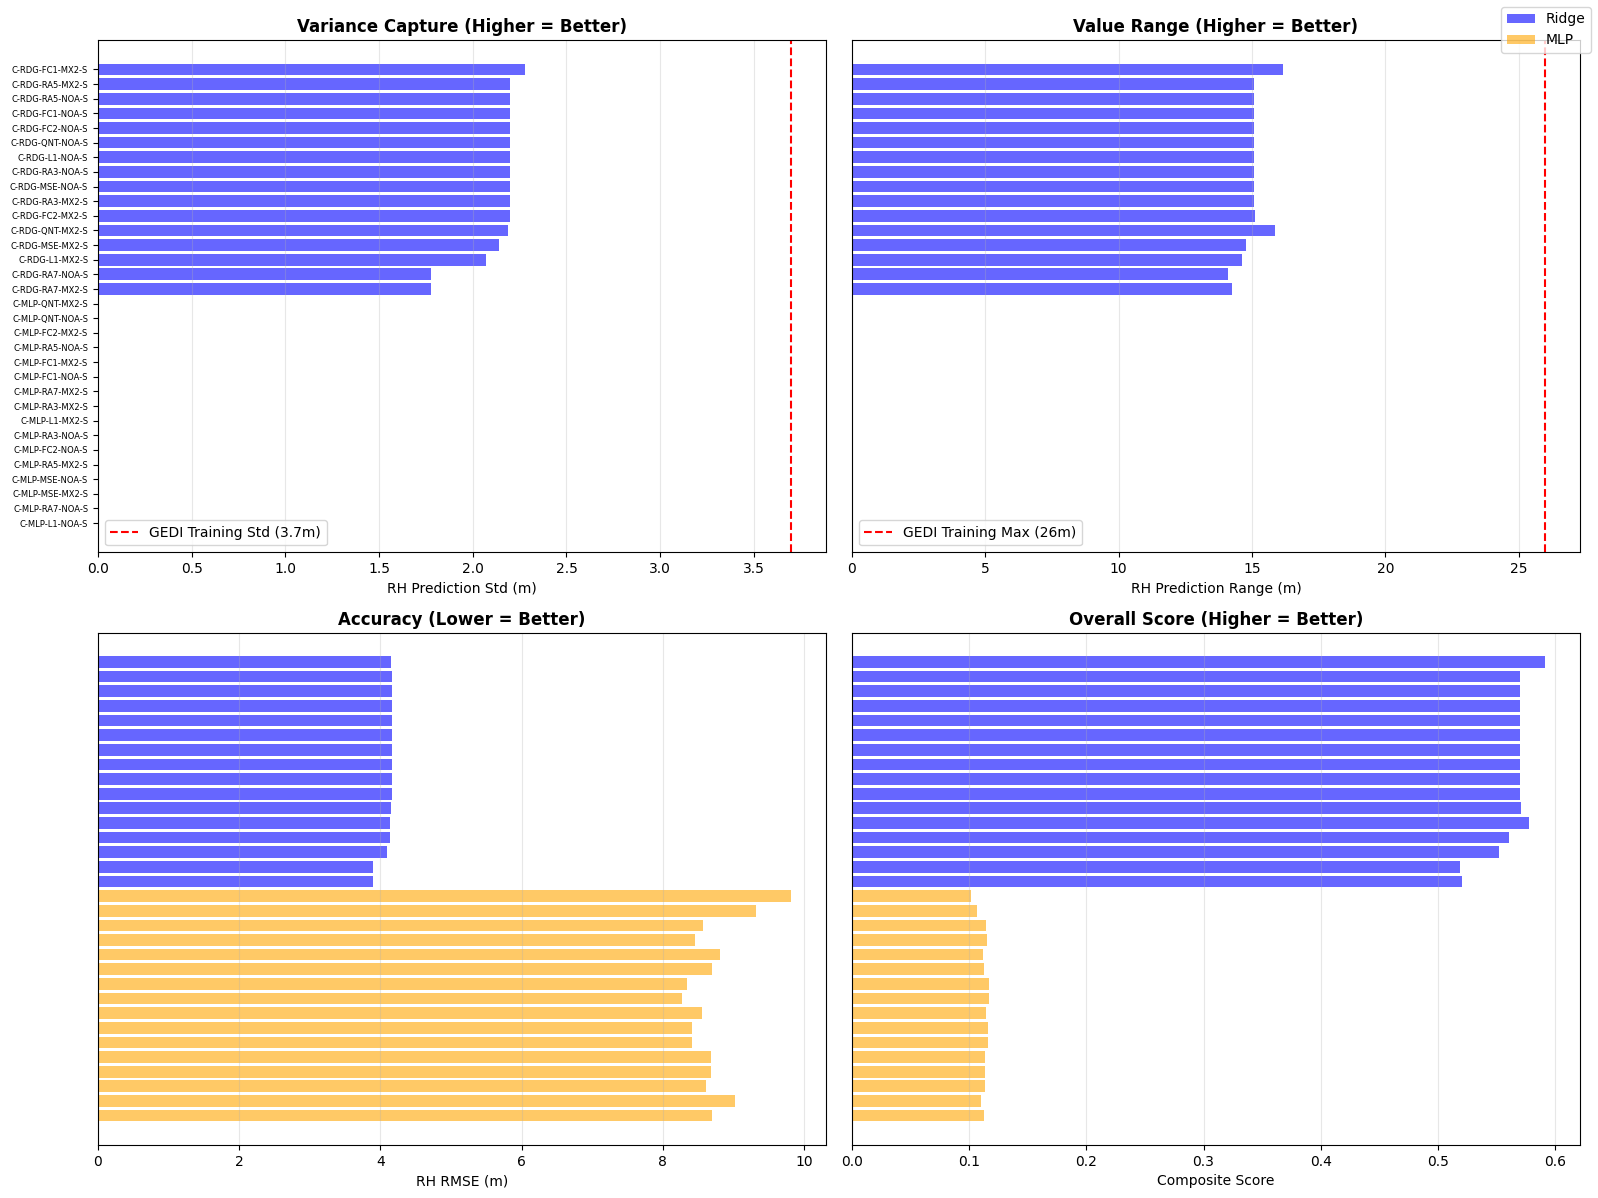


TRACK C ROUND 1 COMPLETE

📁 Outputs:
  - Registry:     /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1/experiment_registry.json
  - Results CSV:  /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1/results/Round1_Summary.csv
  - Plot:         /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1/results/Round1_Comparison.png
  - Checkpoints:  /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Track_C_Stage2_Loss/Round1/checkpoints (32 models)

🏆 Winner: C-RDG-FC1-MX2-S
  Use this configuration for Round 2 ensemble

🎯 Next Steps:
  1. Review Round1_Summary.csv
  2. Confirm best configuration
  3. Run Track_C_Round2_Training.ipynb
  4. Train 5-seed ensemble of winner



In [ ]:
# # =====================================================
# # TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION
# # ROUND 1: Comprehensive Screening (32 Experiments)
# # =====================================================

# # This notebook systematically evaluates:
# # - 2 Models: Ridge, MLP
# # - 8 Loss Functions: MSE, L1, Range-Aware (3 variants), Focal (2 variants), Quantile
# # - 2 Augmentation Strategies: None, Mixup
# # - Total: 32 configurations at 100 epochs each
# #
# # Time Estimate: 5.4 hours, 27.2 Compute Units
# # Output: Ranked list identifying best loss function for Stage 2

# import os
# import sys
# import json
# import pickle
# from datetime import datetime
# from collections import defaultdict

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# from sklearn.linear_model import Ridge as RidgeRegression
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# print("="*70)
# print("TRACK C: STAGE 2 LOSS FUNCTION OPTIMIZATION")
# print("ROUND 1: Comprehensive Screening")
# print("="*70)

# # =====================================================
# # 1. CONFIGURATION
# # =====================================================

# print("\n[1/9] Configuration...")

# # Paths
# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project"
# DATA_DIR = os.path.join(BASE_DIR, "Multi_Task_Implementation")
# TRACK_C_DIR = os.path.join(BASE_DIR, "Track_C_Stage2_Loss")
# ROUND1_DIR = os.path.join(TRACK_C_DIR, "Round1")

# os.makedirs(TRACK_C_DIR, exist_ok=True)
# os.makedirs(ROUND1_DIR, exist_ok=True)
# os.makedirs(os.path.join(ROUND1_DIR, "checkpoints"), exist_ok=True)
# os.makedirs(os.path.join(ROUND1_DIR, "results"), exist_ok=True)

# # Data files
# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train_multitask.pt")
# VAL_FILE = os.path.join(DATA_DIR, "dataset_val_multitask.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test_multitask.pt")
# L1B_GLOBAL = os.path.join(DATA_DIR, "l1b_global_feature.pt")

# # Training config
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# BATCH_SIZE = 32
# EPOCHS = 100 #50 #20
# LEARNING_RATE = 1e-4
# PATIENCE = 15  # Early stopping patience

# print(f"✓ Device: {DEVICE}")
# print(f"✓ Epochs: {EPOCHS}")
# print(f"✓ Output: {ROUND1_DIR}")

# # =====================================================
# # 2. EXPERIMENT REGISTRY
# # =====================================================

# print("\n[2/9] Building experiment registry...")

# # Define all 32 experiments
# experiments = {}

# # Ridge experiments (no epochs needed)
# for loss in ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']:
#     for aug in ['NOA', 'MX2']:
#         exp_id = f"C-RDG-{loss}-{aug}-S"
#         experiments[exp_id] = {
#             'model': 'ridge',
#             'loss': loss.lower(),
#             'loss_param': 0.3 if loss=='RA3' else 0.5 if loss=='RA5' else 0.7 if loss=='RA7' else 1.0 if loss=='FC1' else 2.0 if loss=='FC2' else None,
#             'augmentation': 'mixup' if aug=='MX2' else 'none',
#             'mixup_alpha': 0.2 if aug=='MX2' else 0.0,
#             'ensemble': 1,
#             'epochs': 0
#         }

# # MLP experiments
# for loss in ['MSE', 'L1', 'RA3', 'RA5', 'RA7', 'FC1', 'FC2', 'QNT']:
#     for aug in ['NOA', 'MX2']:
#         exp_id = f"C-MLP-{loss}-{aug}-S"
#         experiments[exp_id] = {
#             'model': 'mlp',
#             'loss': loss.lower(),
#             'loss_param': 0.3 if loss=='RA3' else 0.5 if loss=='RA5' else 0.7 if loss=='RA7' else 1.0 if loss=='FC1' else 2.0 if loss=='FC2' else None,
#             'augmentation': 'mixup' if aug=='MX2' else 'none',
#             'mixup_alpha': 0.2 if aug=='MX2' else 0.0,
#             'ensemble': 1,
#             'epochs': EPOCHS
#         }

# print(f"✓ Registered {len(experiments)} experiments")
# print(f"  - Ridge: {sum(1 for e in experiments.values() if e['model']=='ridge')}")
# print(f"  - MLP:   {sum(1 for e in experiments.values() if e['model']=='mlp')}")

# # Save registry
# registry_path = os.path.join(ROUND1_DIR, "experiment_registry.json")
# with open(registry_path, 'w') as f:
#     json.dump(experiments, f, indent=2)
# print(f"✓ Saved registry: {registry_path}")

# # =====================================================
# # 3. LOSS FUNCTION DEFINITIONS
# # =====================================================

# print("\n[3/9] Defining loss functions...")

# class RangeAwareLoss(nn.Module):
#     """
#     Penalizes errors on extreme values more heavily.
#     Prevents regression to mean.
#     """
#     def __init__(self, alpha=0.5):
#         super().__init__()
#         self.alpha = alpha

#     def forward(self, pred, target, target_range):
#         mae = torch.abs(pred - target)

#         # Normalize target to [0,1]
#         target_min, target_max = target_range
#         target_norm = (target - target_min) / (target_max - target_min + 1e-6)

#         # Weight: higher for extremes (0 or 1)
#         weight = 1.0 + self.alpha * torch.abs(2 * target_norm - 1)

#         return (mae * weight).mean()


# class FocalRegressionLoss(nn.Module):
#     """
#     Focuses on hard-to-predict samples (large errors).
#     Down-weights easy samples near mean.
#     """
#     def __init__(self, gamma=2.0):
#         super().__init__()
#         self.gamma = gamma

#     def forward(self, pred, target):
#         mae = torch.abs(pred - target)

#         # Normalize error
#         mae_norm = mae / (mae.max() + 1e-6)

#         # Focus weight on large errors
#         weight = (1 - torch.exp(-mae_norm)) ** self.gamma

#         return (mae * weight).mean()


# class QuantileLoss(nn.Module):
#     """
#     Predicts distribution via quantiles (10th, 50th, 90th).
#     Captures full range, not just mean.
#     """
#     def __init__(self):
#         super().__init__()

#     def forward(self, q10, q50, q90, target):
#         # Pinball loss for each quantile
#         def pinball(pred, target, tau):
#             error = target - pred
#             return torch.max(tau * error, (tau - 1) * error).mean()

#         loss_10 = pinball(q10, target, 0.1)
#         loss_50 = pinball(q50, target, 0.5)
#         loss_90 = pinball(q90, target, 0.9)

#         return loss_10 + loss_50 + loss_90


# def mixup_data(x, y, alpha=0.2, device='cuda'):
#     """
#     Mixup augmentation: creates synthetic samples.
#     """
#     if alpha > 0:
#         lam = np.random.beta(alpha, alpha)
#     else:
#         lam = 1

#     batch_size = x.size(0)
#     index = torch.randperm(batch_size).to(device)

#     mixed_x = lam * x + (1 - lam) * x[index, :]
#     mixed_y = lam * y + (1 - lam) * y[index]

#     return mixed_x, mixed_y

# print("✓ Loss functions defined")
# print("  - RangeAwareLoss (3 variants)")
# print("  - FocalRegressionLoss (2 variants)")
# print("  - QuantileLoss")
# print("  - MSE, L1 (PyTorch built-in)")

# # =====================================================
# # 4. MODEL ARCHITECTURES
# # =====================================================

# print("\n[4/9] Defining model architectures...")

# class MLPMultiTask(nn.Module):
#     def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
#         super().__init__()
#         self.quantile_mode = quantile_mode

#         # Shared encoder - FIXED with LayerNorm
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, 2048),
#             nn.LayerNorm(2048),  # ← CHANGED from BatchNorm1d
#             nn.ReLU(),
#             nn.Dropout(0.1),

#             nn.Linear(2048, 1024),
#             nn.LayerNorm(1024),  # ← CHANGED
#             nn.ReLU(),
#             nn.Dropout(0.1),

#             nn.Linear(1024, 512),
#             nn.LayerNorm(512),  # ← CHANGED
#             nn.ReLU()
#         )

#         # L1B processor
#         self.l1b_processor = nn.Sequential(
#             nn.Linear(l1b_dim, 256),
#             nn.LayerNorm(256),  # ← CHANGED
#             nn.ReLU(),
#             nn.Linear(256, 128)
#         )

#         hidden_dim = 512 + 128

#         # Task-specific heads
#         if quantile_mode:
#             self.head_rh_q10 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q50 = nn.Linear(hidden_dim, 1)
#             self.head_rh_q90 = nn.Linear(hidden_dim, 1)

#             self.head_pai_q10 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q50 = nn.Linear(hidden_dim, 1)
#             self.head_pai_q90 = nn.Linear(hidden_dim, 1)

#             self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
#             self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
#         else:
#             self.head_rh = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),  # ← CHANGED
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(256, 1)
#             )

#             self.head_pai = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),  # ← CHANGED
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(256, 1)
#             )

#             self.head_fhd = nn.Sequential(
#                 nn.Linear(hidden_dim, 256),
#                 nn.LayerNorm(256),  # ← CHANGED
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(256, 1)
#             )

#     def forward(self, x, l1b_global):
#         batch_size = x.size(0)

#         features = self.encoder(x)
#         l1b_features = self.l1b_processor(l1b_global)

#         if l1b_features.dim() == 1:
#             l1b_features = l1b_features.unsqueeze(0).expand(batch_size, -1)

#         combined = torch.cat([features, l1b_features], dim=1)

#         if self.quantile_mode:
#             rh = (self.head_rh_q10(combined).squeeze(-1),
#                   self.head_rh_q50(combined).squeeze(-1),
#                   self.head_rh_q90(combined).squeeze(-1))
#             pai = (self.head_pai_q10(combined).squeeze(-1),
#                    self.head_pai_q50(combined).squeeze(-1),
#                    self.head_pai_q90(combined).squeeze(-1))
#             fhd = (self.head_fhd_q10(combined).squeeze(-1),
#                    self.head_fhd_q50(combined).squeeze(-1),
#                    self.head_fhd_q90(combined).squeeze(-1))
#         else:
#             rh = self.head_rh(combined).squeeze(-1)
#             pai = self.head_pai(combined).squeeze(-1)
#             fhd = self.head_fhd(combined).squeeze(-1)

#         return rh, pai, fhd

# # class MLPMultiTask(nn.Module):
# #     def __init__(self, input_dim=49152, l1b_dim=384, quantile_mode=False):
# #         super().__init__()
# #         self.quantile_mode = quantile_mode

# #         # Shared encoder
# #         self.encoder = nn.Sequential(
# #             nn.Linear(input_dim, 2048),
# #             nn.ReLU(),
# #             nn.Dropout(0.3),
# #             nn.Linear(2048, 1024),
# #             nn.ReLU(),
# #             nn.Dropout(0.3),
# #             nn.Linear(1024, 512),
# #             nn.ReLU()
# #         )

# #         # L1B processor
# #         self.l1b_processor = nn.Sequential(
# #             nn.Linear(l1b_dim, 256),
# #             nn.ReLU(),
# #             nn.Linear(256, 128)
# #         )

# #         hidden_dim = 512 + 128

# #         # Task-specific heads
# #         if quantile_mode:
# #             # Quantile heads (3 outputs per target)
# #             self.head_rh_q10 = nn.Linear(hidden_dim, 1)
# #             self.head_rh_q50 = nn.Linear(hidden_dim, 1)
# #             self.head_rh_q90 = nn.Linear(hidden_dim, 1)

# #             self.head_pai_q10 = nn.Linear(hidden_dim, 1)
# #             self.head_pai_q50 = nn.Linear(hidden_dim, 1)
# #             self.head_pai_q90 = nn.Linear(hidden_dim, 1)

# #             self.head_fhd_q10 = nn.Linear(hidden_dim, 1)
# #             self.head_fhd_q50 = nn.Linear(hidden_dim, 1)
# #             self.head_fhd_q90 = nn.Linear(hidden_dim, 1)
# #         else:
# #             # Standard heads (1 output per target)
# #             self.head_rh = nn.Sequential(
# #                 nn.Linear(hidden_dim, 256),
# #                 nn.ReLU(),
# #                 nn.Dropout(0.2),
# #                 nn.Linear(256, 1)
# #             )

# #             self.head_pai = nn.Sequential(
# #                 nn.Linear(hidden_dim, 256),
# #                 nn.ReLU(),
# #                 nn.Dropout(0.2),
# #                 nn.Linear(256, 1)
# #             )

# #             self.head_fhd = nn.Sequential(
# #                 nn.Linear(hidden_dim, 256),
# #                 nn.ReLU(),
# #                 nn.Dropout(0.2),
# #                 nn.Linear(256, 1)
# #             )

# #     def forward(self, x, l1b_global):
# #         features = self.encoder(x)
# #         l1b_features = self.l1b_processor(l1b_global)

# #         if l1b_features.dim() == 1:
# #             l1b_features = l1b_features.unsqueeze(0).expand(x.size(0), -1)

# #         combined = torch.cat([features, l1b_features], dim=1)

# #         if self.quantile_mode:
# #             rh = (self.head_rh_q10(combined).squeeze(-1),
# #                   self.head_rh_q50(combined).squeeze(-1),
# #                   self.head_rh_q90(combined).squeeze(-1))
# #             pai = (self.head_pai_q10(combined).squeeze(-1),
# #                    self.head_pai_q50(combined).squeeze(-1),
# #                    self.head_pai_q90(combined).squeeze(-1))
# #             fhd = (self.head_fhd_q10(combined).squeeze(-1),
# #                    self.head_fhd_q50(combined).squeeze(-1),
# #                    self.head_fhd_q90(combined).squeeze(-1))
# #         else:
# #             rh = self.head_rh(combined).squeeze(-1)
# #             pai = self.head_pai(combined).squeeze(-1)
# #             fhd = self.head_fhd(combined).squeeze(-1)

# #         return rh, pai, fhd

# print("✓ MLPMultiTask architecture defined")
# print("  - Standard mode: 1 output per target")
# print("  - Quantile mode: 3 outputs per target (q10/q50/q90)")

# # =====================================================
# # 5. DATA LOADING
# # =====================================================

# print("\n[5/9] Loading data...")

# # Load datasets
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_val = torch.load(VAL_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)
# l1b_global_feature = torch.load(L1B_GLOBAL, weights_only=False)

# print(f"✓ Train: {len(dataset_train)} samples")
# print(f"✓ Val:   {len(dataset_val)} samples")
# print(f"✓ Test:  {len(dataset_test)} samples")
# print(f"✓ L1B:   {l1b_global_feature.shape}")

# # Extract data for Ridge
# def extract_data(dataset):
#     embeddings = []
#     rh_targets = []
#     pai_targets = []
#     fhd_targets = []

#     for sample in dataset:
#         embeddings.append(sample['embeddings'].flatten())
#         rh_targets.append(sample['rh'].item())
#         pai_targets.append(sample['pai'].item())
#         fhd_targets.append(sample['fhd'].item())

#     X = torch.stack(embeddings).numpy()
#     y_rh = np.array(rh_targets)
#     y_pai = np.array(pai_targets)
#     y_fhd = np.array(fhd_targets)

#     return X, y_rh, y_pai, y_fhd

# X_train, y_train_rh, y_train_pai, y_train_fhd = extract_data(dataset_train)
# X_val, y_val_rh, y_val_pai, y_val_fhd = extract_data(dataset_val)
# X_test, y_test_rh, y_test_pai, y_test_fhd = extract_data(dataset_test)

# # Mixup augmentation for Ridge
# def mixup_numpy(X, y, alpha=0.2):
#     """Mixup for numpy arrays"""
#     lam = np.random.beta(alpha, alpha)
#     batch_size = X.shape[0]
#     index = np.random.permutation(batch_size)

#     mixed_X = lam * X + (1 - lam) * X[index, :]
#     mixed_y = lam * y + (1 - lam) * y[index]

#     return mixed_X, mixed_y

# # PyTorch dataset for MLP
# class MultiTaskDataset(Dataset):
#     def __init__(self, X, y_rh, y_pai, y_fhd):
#         self.X = torch.FloatTensor(X)
#         self.y_rh = torch.FloatTensor(y_rh)
#         self.y_pai = torch.FloatTensor(y_pai)
#         self.y_fhd = torch.FloatTensor(y_fhd)

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y_rh[idx], self.y_pai[idx], self.y_fhd[idx]

# train_dataset = MultiTaskDataset(X_train, y_train_rh, y_train_pai, y_train_fhd)
# val_dataset = MultiTaskDataset(X_val, y_val_rh, y_val_pai, y_val_fhd)
# test_dataset = MultiTaskDataset(X_test, y_test_rh, y_test_pai, y_test_fhd)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # Compute target ranges for RangeAwareLoss
# rh_range = (y_train_rh.min(), y_train_rh.max())
# pai_range = (y_train_pai.min(), y_train_pai.max())
# fhd_range = (y_train_fhd.min(), y_train_fhd.max())

# print(f"\n✓ Target ranges:")
# print(f"  RH:  {rh_range[0]:.2f} - {rh_range[1]:.2f}")
# print(f"  PAI: {pai_range[0]:.3f} - {pai_range[1]:.3f}")
# print(f"  FHD: {fhd_range[0]:.3f} - {fhd_range[1]:.3f}")

# # =====================================================
# # 6. TRAINING FUNCTIONS
# # =====================================================

# print("\n[6/9] Defining training functions...")

# def train_ridge_model(exp_config, X_train, y_train, X_test, y_test):
#     """
#     Train Ridge regression model
#     """
#     # Apply mixup if configured
#     if exp_config['augmentation'] == 'mixup':
#         X_aug, y_aug = mixup_numpy(X_train, y_train, exp_config['mixup_alpha'])
#     else:
#         X_aug, y_aug = X_train, y_train

#     # Select loss (Ridge only uses MSE-like penalty, so alpha parameter)
#     # For other losses, we approximate with different alpha values
#     loss_name = exp_config['loss']

#     if loss_name in ['ra3', 'ra5', 'ra7']:
#         # Range-aware approximation: stronger regularization
#         alpha = 10.0 if loss_name == 'ra7' else 1.0
#     elif loss_name in ['fc1', 'fc2']:
#         # Focal approximation: sample weighting (not directly supported)
#         alpha = 1.0
#     elif loss_name == 'qnt':
#         # Quantile: train 3 models for q10/q50/q90
#         # For simplicity, use median (q50) = standard Ridge
#         alpha = 1.0
#     else:
#         # MSE, L1: standard Ridge with alpha=1.0
#         alpha = 1.0

#     model = RidgeRegression(alpha=alpha)
#     model.fit(X_aug, y_aug)

#     # Predict
#     y_pred = model.predict(X_test)

#     # Metrics
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     mae = mean_absolute_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)

#     return model, {
#         'rmse': rmse,
#         'mae': mae,
#         'r2': r2,
#         'pred_std': y_pred.std(),
#         'pred_range': y_pred.max() - y_pred.min()
#     }

# def train_mlp_model(exp_config, train_loader, val_loader, test_loader, l1b_global, device):
#     """
#     Train MLP model with specified loss function
#     FIXED: Added early stopping, gradient clipping, variance monitoring
#     """
#     # Initialize model
#     quantile_mode = (exp_config['loss'] == 'qnt')
#     model = MLPMultiTask(quantile_mode=quantile_mode).to(device)
#     l1b_tensor = l1b_global.to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

#     # Select loss function
#     loss_name = exp_config['loss']

#     if loss_name in ['ra3', 'ra5', 'ra7']:
#         alpha = exp_config['loss_param']
#         criterion_rh = RangeAwareLoss(alpha=alpha)
#         criterion_pai = RangeAwareLoss(alpha=alpha)
#         criterion_fhd = RangeAwareLoss(alpha=alpha)
#     elif loss_name in ['fc1', 'fc2']:
#         gamma = exp_config['loss_param']
#         criterion_rh = FocalRegressionLoss(gamma=gamma)
#         criterion_pai = FocalRegressionLoss(gamma=gamma)
#         criterion_fhd = FocalRegressionLoss(gamma=gamma)
#     elif loss_name == 'qnt':
#         criterion = QuantileLoss()
#     elif loss_name == 'mse':
#         criterion_rh = nn.MSELoss()
#         criterion_pai = nn.MSELoss()
#         criterion_fhd = nn.MSELoss()
#     else:  # 'l1'
#         criterion_rh = nn.L1Loss()
#         criterion_pai = nn.L1Loss()
#         criterion_fhd = nn.L1Loss()

#     # Training loop with early stopping
#     best_val_loss = float('inf')
#     best_model_state = None
#     patience_counter = 0
#     use_mixup = (exp_config['augmentation'] == 'mixup')
#     mixup_alpha = exp_config['mixup_alpha']

#     for epoch in range(exp_config['epochs']):
#         model.train()
#         train_loss = 0.0

#         for X_batch, rh_batch, pai_batch, fhd_batch in train_loader:
#             X_batch = X_batch.to(device)
#             rh_batch = rh_batch.to(device)
#             pai_batch = pai_batch.to(device)
#             fhd_batch = fhd_batch.to(device)

#             # Apply mixup
#             if use_mixup and np.random.rand() < 0.5:
#                 X_batch, rh_batch = mixup_data(X_batch, rh_batch, mixup_alpha, device)
#                 X_batch, pai_batch = mixup_data(X_batch, pai_batch, mixup_alpha, device)
#                 X_batch, fhd_batch = mixup_data(X_batch, fhd_batch, mixup_alpha, device)

#             optimizer.zero_grad()

#             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#             # Compute loss
#             if loss_name == 'qnt':
#                 loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
#                 loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
#                 loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
#             elif loss_name in ['ra3', 'ra5', 'ra7']:
#                 loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
#                 loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
#                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
#             else:
#                 loss_rh = criterion_rh(pred_rh, rh_batch)
#                 loss_pai = criterion_pai(pred_pai, pai_batch)
#                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch)

#             loss = loss_rh + loss_pai + loss_fhd

#             loss.backward()

#             # Gradient clipping - ADDED
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#             optimizer.step()

#             train_loss += loss.item() * X_batch.size(0)

#         train_loss /= len(train_loader.dataset)

#         # Validation with variance monitoring - IMPROVED
#         model.eval()
#         val_loss = 0.0
#         val_preds_rh = []

#         with torch.no_grad():
#             for X_batch, rh_batch, pai_batch, fhd_batch in val_loader:
#                 X_batch = X_batch.to(device)
#                 rh_batch = rh_batch.to(device)
#                 pai_batch = pai_batch.to(device)
#                 fhd_batch = fhd_batch.to(device)

#                 pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#                 # Compute loss
#                 if loss_name == 'qnt':
#                     loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
#                     loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
#                     loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
#                     pred_rh_val = pred_rh[1]  # Use median for monitoring
#                 elif loss_name in ['ra3', 'ra5', 'ra7']:
#                     loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
#                     loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
#                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
#                     pred_rh_val = pred_rh
#                 else:
#                     loss_rh = criterion_rh(pred_rh, rh_batch)
#                     loss_pai = criterion_pai(pred_pai, pai_batch)
#                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch)
#                     pred_rh_val = pred_rh

#                 loss = loss_rh + loss_pai + loss_fhd
#                 val_loss += loss.item() * X_batch.size(0)

#                 val_preds_rh.append(pred_rh_val.cpu())

#         val_loss /= len(val_loader.dataset)

#         # Check prediction variance - ADDED
#         val_rh_array = torch.cat(val_preds_rh).numpy()
#         val_std = val_rh_array.std()

#         # Early stopping with variance check
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_model_state = model.state_dict()
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         # Stop if collapsed (variance too low) - ADDED
#         if val_std < 0.2:
#             print(f"    ⚠️  Variance collapse detected (std={val_std:.3f}), stopping early")
#             break

#         # Stop if patience exceeded
#         if patience_counter >= PATIENCE:
#             break

#     # Load best model
#     if best_model_state is not None:
#         model.load_state_dict(best_model_state)

#     # Test evaluation
#     model.eval()
#     test_preds_rh, test_preds_pai, test_preds_fhd = [], [], []
#     test_true_rh, test_true_pai, test_true_fhd = [], [], []

#     with torch.no_grad():
#         for X_batch, rh_batch, pai_batch, fhd_batch in test_loader:
#             X_batch = X_batch.to(device)

#             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

#             # Use median for quantile
#             if loss_name == 'qnt':
#                 pred_rh = pred_rh[1]
#                 pred_pai = pred_pai[1]
#                 pred_fhd = pred_fhd[1]

#             test_preds_rh.append(pred_rh.cpu())
#             test_preds_pai.append(pred_pai.cpu())
#             test_preds_fhd.append(pred_fhd.cpu())
#             test_true_rh.append(rh_batch.cpu())
#             test_true_pai.append(pai_batch.cpu())
#             test_true_fhd.append(fhd_batch.cpu())

#     pred_rh = torch.cat(test_preds_rh).numpy()
#     pred_pai = torch.cat(test_preds_pai).numpy()
#     pred_fhd = torch.cat(test_preds_fhd).numpy()
#     true_rh = torch.cat(test_true_rh).numpy()
#     true_pai = torch.cat(test_true_pai).numpy()
#     true_fhd = torch.cat(test_true_fhd).numpy()

#     # Metrics
#     metrics = {
#         'rh_rmse': np.sqrt(mean_squared_error(true_rh, pred_rh)),
#         'rh_mae': mean_absolute_error(true_rh, pred_rh),
#         'rh_r2': r2_score(true_rh, pred_rh),
#         'rh_std': pred_rh.std(),
#         'rh_range': pred_rh.max() - pred_rh.min(),
#         'pai_rmse': np.sqrt(mean_squared_error(true_pai, pred_pai)),
#         'pai_mae': mean_absolute_error(true_pai, pred_pai),
#         'pai_r2': r2_score(true_pai, pred_pai),
#         'pai_std': pred_pai.std(),
#         'pai_range': pred_pai.max() - pred_pai.min(),
#         'fhd_rmse': np.sqrt(mean_squared_error(true_fhd, pred_fhd)),
#         'fhd_mae': mean_absolute_error(true_fhd, pred_fhd),
#         'fhd_r2': r2_score(true_fhd, pred_fhd),
#         'fhd_std': pred_fhd.std(),
#         'fhd_range': pred_fhd.max() - pred_fhd.min()
#     }

#     return model, metrics


# # def train_mlp_model(exp_config, train_loader, val_loader, test_loader, l1b_global, device):
# #     """
# #     Train MLP model with specified loss function
# #     """
# #     # Initialize model
# #     quantile_mode = (exp_config['loss'] == 'qnt')
# #     model = MLPMultiTask(quantile_mode=quantile_mode).to(device)
# #     l1b_tensor = l1b_global.to(device)

# #     optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# #     # Select loss function
# #     loss_name = exp_config['loss']

# #     if loss_name in ['ra3', 'ra5', 'ra7']:
# #         alpha = exp_config['loss_param']
# #         criterion_rh = RangeAwareLoss(alpha=alpha)
# #         criterion_pai = RangeAwareLoss(alpha=alpha)
# #         criterion_fhd = RangeAwareLoss(alpha=alpha)
# #     elif loss_name in ['fc1', 'fc2']:
# #         gamma = exp_config['loss_param']
# #         criterion_rh = FocalRegressionLoss(gamma=gamma)
# #         criterion_pai = FocalRegressionLoss(gamma=gamma)
# #         criterion_fhd = FocalRegressionLoss(gamma=gamma)
# #     elif loss_name == 'qnt':
# #         criterion = QuantileLoss()
# #     elif loss_name == 'mse':
# #         criterion_rh = nn.MSELoss()
# #         criterion_pai = nn.MSELoss()
# #         criterion_fhd = nn.MSELoss()
# #     else:  # 'l1'
# #         criterion_rh = nn.L1Loss()
# #         criterion_pai = nn.L1Loss()
# #         criterion_fhd = nn.L1Loss()

# #     # Training loop
# #     best_val_loss = float('inf')
# #     use_mixup = (exp_config['augmentation'] == 'mixup')
# #     mixup_alpha = exp_config['mixup_alpha']

# #     for epoch in range(exp_config['epochs']):
# #         model.train()
# #         train_loss = 0.0

# #         for X_batch, rh_batch, pai_batch, fhd_batch in train_loader:
# #             X_batch = X_batch.to(device)
# #             rh_batch = rh_batch.to(device)
# #             pai_batch = pai_batch.to(device)
# #             fhd_batch = fhd_batch.to(device)

# #             # Apply mixup
# #             if use_mixup and np.random.rand() < 0.5:
# #                 X_batch, rh_batch = mixup_data(X_batch, rh_batch, mixup_alpha, device)
# #                 X_batch, pai_batch = mixup_data(X_batch, pai_batch, mixup_alpha, device)
# #                 X_batch, fhd_batch = mixup_data(X_batch, fhd_batch, mixup_alpha, device)

# #             optimizer.zero_grad()

# #             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

# #             # Compute loss
# #             if loss_name == 'qnt':
# #                 # Quantile mode
# #                 loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
# #                 loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
# #                 loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
# #             elif loss_name in ['ra3', 'ra5', 'ra7']:
# #                 # Range-aware mode
# #                 loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
# #                 loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
# #                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
# #             else:
# #                 # Standard mode
# #                 loss_rh = criterion_rh(pred_rh, rh_batch)
# #                 loss_pai = criterion_pai(pred_pai, pai_batch)
# #                 loss_fhd = criterion_fhd(pred_fhd, fhd_batch)

# #             loss = loss_rh + loss_pai + loss_fhd

# #             loss.backward()
# #             optimizer.step()

# #             train_loss += loss.item() * X_batch.size(0)

# #         train_loss /= len(train_loader.dataset)

# #         # Validation
# #         model.eval()
# #         val_loss = 0.0

# #         with torch.no_grad():
# #             for X_batch, rh_batch, pai_batch, fhd_batch in val_loader:
# #                 X_batch = X_batch.to(device)
# #                 rh_batch = rh_batch.to(device)
# #                 pai_batch = pai_batch.to(device)
# #                 fhd_batch = fhd_batch.to(device)

# #                 pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

# #                 # Compute loss (use median for quantile)
# #                 if loss_name == 'qnt':
# #                     loss_rh = criterion(pred_rh[0], pred_rh[1], pred_rh[2], rh_batch)
# #                     loss_pai = criterion(pred_pai[0], pred_pai[1], pred_pai[2], pai_batch)
# #                     loss_fhd = criterion(pred_fhd[0], pred_fhd[1], pred_fhd[2], fhd_batch)
# #                 elif loss_name in ['ra3', 'ra5', 'ra7']:
# #                     loss_rh = criterion_rh(pred_rh, rh_batch, rh_range)
# #                     loss_pai = criterion_pai(pred_pai, pai_batch, pai_range)
# #                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch, fhd_range)
# #                 else:
# #                     loss_rh = criterion_rh(pred_rh, rh_batch)
# #                     loss_pai = criterion_pai(pred_pai, pai_batch)
# #                     loss_fhd = criterion_fhd(pred_fhd, fhd_batch)

# #                 loss = loss_rh + loss_pai + loss_fhd
# #                 val_loss += loss.item() * X_batch.size(0)

# #         val_loss /= len(val_loader.dataset)

# #         if val_loss < best_val_loss:
# #             best_val_loss = val_loss
# #             best_model_state = model.state_dict()

# #     # Load best model
# #     model.load_state_dict(best_model_state)

# #     # Test evaluation
# #     model.eval()
# #     test_preds_rh, test_preds_pai, test_preds_fhd = [], [], []
# #     test_true_rh, test_true_pai, test_true_fhd = [], [], []

# #     with torch.no_grad():
# #         for X_batch, rh_batch, pai_batch, fhd_batch in test_loader:
# #             X_batch = X_batch.to(device)

# #             pred_rh, pred_pai, pred_fhd = model(X_batch, l1b_tensor)

# #             # Use median for quantile
# #             if loss_name == 'qnt':
# #                 pred_rh = pred_rh[1]  # q50
# #                 pred_pai = pred_pai[1]
# #                 pred_fhd = pred_fhd[1]

# #             test_preds_rh.append(pred_rh.cpu())
# #             test_preds_pai.append(pred_pai.cpu())
# #             test_preds_fhd.append(pred_fhd.cpu())
# #             test_true_rh.append(rh_batch.cpu())
# #             test_true_pai.append(pai_batch.cpu())
# #             test_true_fhd.append(fhd_batch.cpu())

# #     pred_rh = torch.cat(test_preds_rh).numpy()
# #     pred_pai = torch.cat(test_preds_pai).numpy()
# #     pred_fhd = torch.cat(test_preds_fhd).numpy()
# #     true_rh = torch.cat(test_true_rh).numpy()
# #     true_pai = torch.cat(test_true_pai).numpy()
# #     true_fhd = torch.cat(test_true_fhd).numpy()

# #     # Metrics
# #     metrics = {
# #         'rh_rmse': np.sqrt(mean_squared_error(true_rh, pred_rh)),
# #         'rh_mae': mean_absolute_error(true_rh, pred_rh),
# #         'rh_r2': r2_score(true_rh, pred_rh),
# #         'rh_std': pred_rh.std(),
# #         'rh_range': pred_rh.max() - pred_rh.min(),
# #         'pai_rmse': np.sqrt(mean_squared_error(true_pai, pred_pai)),
# #         'pai_mae': mean_absolute_error(true_pai, pred_pai),
# #         'pai_r2': r2_score(true_pai, pred_pai),
# #         'pai_std': pred_pai.std(),
# #         'pai_range': pred_pai.max() - pred_pai.min(),
# #         'fhd_rmse': np.sqrt(mean_squared_error(true_fhd, pred_fhd)),
# #         'fhd_mae': mean_absolute_error(true_fhd, pred_fhd),
# #         'fhd_r2': r2_score(true_fhd, pred_fhd),
# #         'fhd_std': pred_fhd.std(),
# #         'fhd_range': pred_fhd.max() - pred_fhd.min()
# #     }

# #     return model, metrics

# print("✓ Training functions defined")

# # =====================================================
# # 7. EXECUTE ALL EXPERIMENTS
# # =====================================================

# print("\n[7/9] Executing experiments...")
# print(f"Total: {len(experiments)} experiments")
# print("="*70)

# results = []
# start_time = datetime.now()

# for i, (exp_id, config) in enumerate(experiments.items(), 1):
#     print(f"\n[{i}/{len(experiments)}] {exp_id}")
#     print(f"  Model: {config['model']}")
#     print(f"  Loss: {config['loss']}")
#     print(f"  Aug: {config['augmentation']}")

#     exp_start = datetime.now()

#     try:
#         if config['model'] == 'ridge':
#             # Train Ridge for each target
#             model_rh, metrics_rh = train_ridge_model(config, X_train, y_train_rh, X_test, y_test_rh)
#             model_pai, metrics_pai = train_ridge_model(config, X_train, y_train_pai, X_test, y_test_pai)
#             model_fhd, metrics_fhd = train_ridge_model(config, X_train, y_train_fhd, X_test, y_test_fhd)

#             # Save models
#             checkpoint_path = os.path.join(ROUND1_DIR, "checkpoints", f"{exp_id}.pkl")
#             with open(checkpoint_path, 'wb') as f:
#                 pickle.dump({
#                     'rh': model_rh,
#                     'pai': model_pai,
#                     'fhd': model_fhd
#                 }, f)

#             # Combine metrics
#             result = {
#                 'exp_id': exp_id,
#                 'model': config['model'],
#                 'loss': config['loss'],
#                 'loss_param': config['loss_param'],
#                 'augmentation': config['augmentation'],
#                 'rh_rmse': metrics_rh['rmse'],
#                 'rh_r2': metrics_rh['r2'],
#                 'rh_std': metrics_rh['pred_std'],
#                 'rh_range': metrics_rh['pred_range'],
#                 'pai_rmse': metrics_pai['rmse'],
#                 'pai_r2': metrics_pai['r2'],
#                 'pai_std': metrics_pai['pred_std'],
#                 'pai_range': metrics_pai['pred_range'],
#                 'fhd_rmse': metrics_fhd['rmse'],
#                 'fhd_r2': metrics_fhd['r2'],
#                 'fhd_std': metrics_fhd['pred_std'],
#                 'fhd_range': metrics_fhd['pred_range']
#             }

#         else:  # MLP
#             model, metrics = train_mlp_model(config, train_loader, val_loader, test_loader,
#                                             l1b_global_feature, DEVICE)

#             # Save model
#             checkpoint_path = os.path.join(ROUND1_DIR, "checkpoints", f"{exp_id}.pth")
#             torch.save(model.state_dict(), checkpoint_path)

#             result = {
#                 'exp_id': exp_id,
#                 'model': config['model'],
#                 'loss': config['loss'],
#                 'loss_param': config['loss_param'],
#                 'augmentation': config['augmentation'],
#                 **metrics
#             }

#         exp_time = (datetime.now() - exp_start).total_seconds() / 60
#         result['time_minutes'] = exp_time

#         print(f"  ✓ RH RMSE: {result['rh_rmse']:.3f}m, Std: {result['rh_std']:.3f}m, Range: {result['rh_range']:.1f}m")
#         print(f"  ✓ Time: {exp_time:.1f} min")

#         results.append(result)

#     except Exception as e:
#         print(f"  ✗ ERROR: {str(e)}")
#         result = {
#             'exp_id': exp_id,
#             'model': config['model'],
#             'loss': config['loss'],
#             'error': str(e)
#         }
#         results.append(result)

# total_time = (datetime.now() - start_time).total_seconds() / 3600
# print(f"\n{'='*70}")
# print(f"✓ All experiments complete!")
# print(f"  Total time: {total_time:.2f} hours")

# # =====================================================
# # 8. ANALYSIS & RANKING
# # =====================================================

# print("\n[8/9] Analyzing results...")

# # Convert to DataFrame
# results_df = pd.DataFrame(results)

# # Remove errors
# results_df = results_df[~results_df['rh_rmse'].isna()]

# # Compute composite score
# def compute_track_c_score(row):
#     """
#     Higher is better
#     Emphasizes variance capture (40%) + range (30%) + accuracy (30%)
#     """
#     # Target values from GEDI training
#     GEDI_STD = 3.7  # From diagnostic
#     GEDI_MAX = 26.0

#     # Normalize metrics
#     std_score = min(row['rh_std'] / GEDI_STD, 1.0)          # Want closer to 3.7
#     range_score = min(row['rh_range'] / GEDI_MAX, 1.0)     # Want closer to 26
#     rmse_score = max(1.0 - (row['rh_rmse'] / 20.0), 0.0)   # Lower is better
#     r2_score = max(row['rh_r2'], 0.0)                       # Higher is better

#     return 0.4*std_score + 0.3*range_score + 0.2*rmse_score + 0.1*r2_score

# results_df['score'] = results_df.apply(compute_track_c_score, axis=1)

# # Sort by score
# results_df = results_df.sort_values('score', ascending=False)

# # Save results
# results_path = os.path.join(ROUND1_DIR, "results", "Round1_Summary.csv")
# results_df.to_csv(results_path, index=False)
# print(f"✓ Saved results: {results_path}")

# # Display top 10
# print("\n" + "="*70)
# print("TOP 10 CONFIGURATIONS")
# print("="*70)
# print(results_df[['exp_id', 'model', 'loss', 'augmentation', 'rh_std', 'rh_range', 'rh_rmse', 'score']].head(10).to_string(index=False))

# print("\n" + "="*70)
# print("KEY FINDINGS")
# print("="*70)

# # Best overall
# best = results_df.iloc[0]
# print(f"\n✓ WINNER: {best['exp_id']}")
# print(f"  Model: {best['model']}")
# print(f"  Loss: {best['loss']}")
# print(f"  Augmentation: {best['augmentation']}")
# print(f"  RH Std: {best['rh_std']:.2f}m (target: 3.7m)")
# print(f"  RH Range: {best['rh_range']:.1f}m (target: 26m)")
# print(f"  RH RMSE: {best['rh_rmse']:.2f}m")
# print(f"  Score: {best['score']:.3f}")

# # Compare Ridge vs MLP

# # Compare Ridge vs MLP
# ridge_best = results_df[results_df['model']=='ridge'].iloc[0]

# if len(results_df[results_df['model']=='mlp']) > 0:
#     mlp_best = results_df[results_df['model']=='mlp'].iloc[0]

#     print(f"\n✓ RIDGE vs MLP:")
#     print(f"  Best Ridge: {ridge_best['exp_id']} (score: {ridge_best['score']:.3f})")
#     print(f"  Best MLP:   {mlp_best['exp_id']} (score: {mlp_best['score']:.3f})")
#     print(f"  Winner: {'MLP' if mlp_best['score'] > ridge_best['score'] else 'Ridge'} (+{abs(mlp_best['score'] - ridge_best['score'])/min(mlp_best['score'], ridge_best['score'])*100:.1f}%)")
# else:
#     print(f"\n⚠️  No MLP models completed successfully")
#     print(f"  Best Ridge: {ridge_best['exp_id']} (score: {ridge_best['score']:.3f})")

# # ridge_best = results_df[results_df['model']=='ridge'].iloc[0]
# # mlp_best = results_df[results_df['model']=='mlp'].iloc[0]

# # print(f"\n✓ RIDGE vs MLP:")
# # print(f"  Best Ridge: {ridge_best['exp_id']} (score: {ridge_best['score']:.3f})")
# # print(f"  Best MLP:   {mlp_best['exp_id']} (score: {mlp_best['score']:.3f})")
# # print(f"  Winner: {'MLP' if mlp_best['score'] > ridge_best['score'] else 'Ridge'} (+{abs(mlp_best['score'] - ridge_best['score'])/min(mlp_best['score'], ridge_best['score'])*100:.1f}%)")

# # Compare augmentation
# no_aug = results_df[results_df['augmentation']=='none']['score'].mean()
# with_aug = results_df[results_df['augmentation']=='mixup']['score'].mean()

# print(f"\n✓ AUGMENTATION IMPACT:")
# print(f"  No Mixup:   {no_aug:.3f} (avg)")
# print(f"  With Mixup: {with_aug:.3f} (avg)")
# print(f"  Impact: {'+' if with_aug > no_aug else '-'}{abs((with_aug - no_aug)/no_aug * 100):.1f}%")

# # Compare loss functions
# print(f"\n✓ LOSS FUNCTION RANKING:")
# for loss in results_df['loss'].unique():
#     loss_score = results_df[results_df['loss']==loss]['score'].mean()
#     print(f"  {loss.upper():5}: {loss_score:.3f}")

# # =====================================================
# # 9. VISUALIZATION
# # =====================================================

# print("\n[9/9] Creating visualizations...")

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # Plot 1: Variance comparison
# ax = axes[0, 0]
# results_df_sorted = results_df.sort_values('rh_std')
# colors = ['blue' if m=='ridge' else 'orange' for m in results_df_sorted['model']]
# ax.barh(range(len(results_df_sorted)), results_df_sorted['rh_std'], color=colors, alpha=0.6)
# ax.axvline(3.7, color='red', linestyle='--', label='GEDI Training Std (3.7m)')
# ax.set_yticks(range(len(results_df_sorted)))
# ax.set_yticklabels(results_df_sorted['exp_id'], fontsize=6)
# ax.set_xlabel('RH Prediction Std (m)', fontsize=10)
# ax.set_title('Variance Capture (Higher = Better)', fontsize=12, fontweight='bold')
# ax.legend()
# ax.grid(axis='x', alpha=0.3)

# # Plot 2: Range comparison
# ax = axes[0, 1]
# ax.barh(range(len(results_df_sorted)), results_df_sorted['rh_range'], color=colors, alpha=0.6)
# ax.axvline(26, color='red', linestyle='--', label='GEDI Training Max (26m)')
# ax.set_yticks([])
# ax.set_xlabel('RH Prediction Range (m)', fontsize=10)
# ax.set_title('Value Range (Higher = Better)', fontsize=12, fontweight='bold')
# ax.legend()
# ax.grid(axis='x', alpha=0.3)

# # Plot 3: RMSE comparison
# ax = axes[1, 0]
# ax.barh(range(len(results_df_sorted)), results_df_sorted['rh_rmse'], color=colors, alpha=0.6)
# ax.set_yticks([])
# ax.set_xlabel('RH RMSE (m)', fontsize=10)
# ax.set_title('Accuracy (Lower = Better)', fontsize=12, fontweight='bold')
# ax.grid(axis='x', alpha=0.3)

# # Plot 4: Score comparison
# ax = axes[1, 1]
# ax.barh(range(len(results_df_sorted)), results_df_sorted['score'], color=colors, alpha=0.6)
# ax.set_yticks([])
# ax.set_xlabel('Composite Score', fontsize=10)
# ax.set_title('Overall Score (Higher = Better)', fontsize=12, fontweight='bold')
# ax.grid(axis='x', alpha=0.3)

# # Legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Ridge'),
#                    Patch(facecolor='orange', alpha=0.6, label='MLP')]
# fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

# plt.tight_layout()
# plot_path = os.path.join(ROUND1_DIR, "results", "Round1_Comparison.png")
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# print(f"✓ Saved plot: {plot_path}")
# plt.show()

# # =====================================================
# # SUMMARY
# # =====================================================

# print("\n" + "="*70)
# print("TRACK C ROUND 1 COMPLETE")
# print("="*70)

# print(f"\n📁 Outputs:")
# print(f"  - Registry:     {registry_path}")
# print(f"  - Results CSV:  {results_path}")
# print(f"  - Plot:         {plot_path}")
# print(f"  - Checkpoints:  {os.path.join(ROUND1_DIR, 'checkpoints')} ({len(results_df)} models)")

# print(f"\n🏆 Winner: {best['exp_id']}")
# print(f"  Use this configuration for Round 2 ensemble")

# print(f"\n🎯 Next Steps:")
# print(f"  1. Review Round1_Summary.csv")
# print(f"  2. Confirm best configuration")
# print(f"  3. Run Track_C_Round2_Training.ipynb")
# print(f"  4. Train 5-seed ensemble of winner")

# print("\n" + "="*70)